In [26]:
import numpy as np
import pandas as pd
import matplotlib as mpl
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
import umap
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
import umap
import crepes
import seaborn as sns
import matplotlib.pyplot as plt
from nonconformist.base import BaseModelAdapter
from nonconformist.nc import MarginErrFunc
from nonconformist.cp import TcpClassifier 
from sklearn.base import BaseEstimator

# 300 dpi
mpl.rcParams['figure.dpi'] = 300
# settings to display more columns and rows
pd.set_option("max_colwidth", 200)
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

In [27]:
# Set print options to display the full array
np.set_printoptions(threshold=np.inf)  # Remove the threshold for truncation


In [59]:

from conf_eval import metrics, plot
import matplotlib.pyplot as plt # For customizations 
import numpy as np # Loading of data

# Set a different style and context
plot.update_plot_settings(context='talk', font_scale=1.5)

In [159]:

# Load the data
filtered_df = '/home/jovyan/share/data/analyses/sofia/kinase378-vt1/CellProfiler/U2OS/df_test_pred.csv'
df = pd.read_csv(f'{filtered_df}', sep=';', index_col=0)

# Prepare the features (X) and target (y)
X = df.drop(columns=['Family', 'ReplicateGroup', 'cmpd_conc'] + df.columns[-28:].tolist())  # Features (excluding metadata and target)
y = df['Family']  # Target (Family column
# Prepare the features (X) and target (y)
# Group by 'Family' and collect unique compound IDs
group_map = df.groupby('Family')['compound_id'].unique().apply(list).to_dict()

# Display the result
group_map

/tmp/ipykernel_795625/177517357.py:3: DtypeWarning: Columns (1447) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f'{filtered_df}', sep=';', index_col=0)


{'AUR': ['CBK288286G',
  'CBK290482',
  'CBK277972',
  'CBK277955',
  'CBK288285',
  'CBK288288',
  'CBK290772',
  'CBK288281',
  'CBK290801',
  'CBK288282',
  'CBK288349',
  'CBK278064',
  'CBK293886',
  'CBK288284'],
 'Akt': ['CBK201383',
  'CBK277971C',
  'CBK290756',
  'CBK288338',
  'CBK278103',
  'CBK293872',
  'CBK293866',
  'CBK290956',
  'CBK290457C'],
 'CAMKL': ['CBK288348',
  'CBK278040',
  'CBK293853',
  'CBK277954',
  'CBK293882',
  'CBK290745'],
 'CDK': ['CBK277936',
  'CBK278001',
  'CBK288278',
  'CBK288280',
  'CBK277922C',
  'CBK288279C',
  'CBK290797',
  'CBK288335',
  'CBK290823',
  'CBK277941C',
  'CBK290859',
  'CBK278081',
  'CBK290752',
  'CBK290998',
  'CBK293881',
  'CBK293858C',
  'CBK293860G',
  'CBK293896'],
 'DMPK': ['CBK290556', 'CBK041232C', 'CBK290561', 'CBK293862'],
 'PIKK': ['CBK288312',
  'CBK277993',
  'CBK277967',
  'CBK277956',
  'CBK041801',
  'CBK288329',
  'CBK278051',
  'CBK288307',
  'CBK288313',
  'CBK288346',
  'CBK277965',
  'CBK288341',
 

In [28]:
# Assuming 'df' is the DataFrame and 'X' (features) and 'y' (target) are already defined

# Split the data into training, calibration, and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5)

X_prop_train, X_cal, y_prop_train, y_cal = train_test_split(X_train, y_train,test_size=0.25)

# Verify the distribution of families in each set
print("Training set family distribution:\n", y_train.value_counts())
print("\nCalibration set family distribution:\n", y_cal.value_counts())
print("\nTest set family distribution:\n", y_test.value_counts())

Training set family distribution:
 Family
PIKK     358
CDK      275
AUR      204
Akt      116
PLK      108
CAMKL     89
Src       83
DMPK      72
Name: count, dtype: int64

Calibration set family distribution:
 Family
PIKK     91
CDK      73
AUR      53
Akt      28
PLK      27
CAMKL    25
Src      17
DMPK     13
Name: count, dtype: int64

Test set family distribution:
 Family
PIKK     336
CDK      275
AUR      233
Akt      133
PLK       95
CAMKL     84
Src       78
DMPK      72
Name: count, dtype: int64


In [183]:
from sklearn.model_selection import train_test_split

# Initialize a random seed for reproducibility (optional)
random_seed = 42  

# Step 1: Split the data into training and test sets (50% test size)
X_train_test, X_test, y_train_test, y_test = train_test_split(
    X, y, test_size=0.5, stratify=y, random_state=random_seed
)

# Step 2: Further split the remaining data into training and calibration sets (25% of training data goes to calibration)
X_train, X_cal, y_train, y_cal = train_test_split(
    X_train_test, y_train_test, test_size=0.25, stratify=y_train_test, random_state=random_seed
)

# Step 3: Verify that compounds are not repeated across splits (Only for Test set)

# Step 4: Print family distributions in each split
print("\nTraining set family distribution:\n", y_train.value_counts(normalize=True) * 100)
print("\nCalibration set family distribution:\n", y_cal.value_counts(normalize=True) * 100)
print("\nTest set family distribution:\n", y_test.value_counts(normalize=True) * 100)


Training set family distribution:
 Family
PIKK     26.584867
CDK      21.063395
AUR      16.666667
Akt       9.509202
PLK       7.770961
CAMKL     6.646217
Src       6.237219
DMPK      5.521472
Name: proportion, dtype: float64

Calibration set family distribution:
 Family
PIKK     26.605505
CDK      21.100917
AUR      16.819572
Akt       9.480122
PLK       7.645260
CAMKL     6.727829
Src       6.116208
DMPK      5.504587
Name: proportion, dtype: float64

Test set family distribution:
 Family
PIKK     26.569678
CDK      21.056662
AUR      16.768760
Akt       9.571210
PLK       7.810107
CAMKL     6.584992
Src       6.125574
DMPK      5.513017
Name: proportion, dtype: float64


In [184]:
"""We will first embed, or “wrap” in the terminology of crepes, a SVM from scikit-learn,
 fit it to the proper training set, and fit a standard conformal classifier through the 
 calibrate method:
 """
from crepes import WrapClassifier
from sklearn.svm import SVC

# Initialize your classifier (usinf SVM as an example, but any model can be used)
SVM = SVC(kernel='rbf', C=1, gamma='scale', probability=True)

# Wrap the classifier with CREPE's WrapClassifier
wrapped_model = WrapClassifier(SVM)

# Train the model on the propositional training data
wrapped_model.fit(X_prop_train, y_prop_train)
# We may now fit a conformal regressor using the calibration set through the calibrate method
wrapped_model.calibrate(X_cal, y_cal)

WrapClassifier(learner=SVC(C=1, probability=True), calibrated=True, predictor=ConformalClassifier(fitted=True, mondrian=False))

In [185]:
prediction_sets = wrapped_model.predict_set(X_test)
display(wrapped_model.learner.classes_)
display(prediction_sets)


array(['AUR', 'Akt', 'CAMKL', 'CDK', 'DMPK', 'PIKK', 'PLK', 'Src'],
      dtype=object)

array([[0, 0, 0, 0, 0, 1, 0, 0],
       [0, 0, 1, 1, 0, 1, 1, 0],
       [1, 0, 0, 0, 0, 0, 0, 0],
       [1, 1, 1, 1, 0, 1, 0, 0],
       [0, 0, 0, 1, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0],
       [0, 1, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 0, 0, 1, 0],
       [1, 0, 0, 0, 0, 0, 0, 0],
       [1, 0, 1, 1, 0, 1, 0, 0],
       [0, 0, 1, 1, 0, 0, 1, 0],
       [0, 0, 0, 1, 0, 0, 0, 0],
       [1, 1, 0, 1, 0, 1, 0, 0],
       [0, 1, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 1],
       [0, 0, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 0, 0, 1, 0],
       [1, 1, 0, 1, 0, 1, 0, 0],
       [1, 0, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 0, 0, 1, 0],
       [1, 0, 1, 1, 0, 1, 0, 1],
       [1, 0, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 1, 0, 0, 0, 0],
       [1, 1, 0, 1, 0, 1, 0, 0],
       [1, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 1, 0, 0, 0, 0],
       [0, 1, 0, 0, 0, 1, 0, 1],
       [0, 0, 1, 1, 0, 0, 1, 0],
       [0, 0, 0, 1, 0, 0, 0, 0],
       [1, 0, 0, 0, 0, 1, 0, 0],
       [1,

In [186]:
true_labels = wrapped_model.learner.classes_
true_labels

array(['AUR', 'Akt', 'CAMKL', 'CDK', 'DMPK', 'PIKK', 'PLK', 'Src'],
      dtype=object)

In [187]:
"""
We can also get prediction sets, represented by binary vectors indicating presence (1) or absence (0)
of the class labels that correspond to the columns, here at the 90% confidence level, using predict set:
"""
prediction_sets = wrapped_model.predict_set(X_test, confidence=0.90)

"""
We may specify any confidence level that we are interested in, e.g., 99%. 
By increasing the confidence level, we can expect to see fewer labels getting rejected:
"""

display(prediction_sets)

array([[0, 0, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0],
       [1, 0, 0, 0, 0, 0, 0, 0],
       [1, 0, 1, 0, 0, 1, 0, 0],
       [0, 0, 0, 1, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0],
       [0, 1, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 0, 0, 1, 0],
       [1, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 1, 0, 0, 1, 0, 0],
       [0, 0, 1, 1, 0, 0, 0, 0],
       [0, 0, 0, 1, 0, 0, 0, 0],
       [1, 0, 0, 1, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 1],
       [0, 0, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 0, 0, 1, 0],
       [1, 0, 0, 1, 0, 1, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 0, 0, 1, 0],
       [1, 0, 1, 0, 0, 1, 0, 1],
       [0, 0, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 1, 0, 0, 0, 0],
       [0, 1, 0, 1, 0, 1, 0, 0],
       [1, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 1, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 1],
       [0, 0, 0, 1, 0, 0, 1, 0],
       [0, 0, 0, 1, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0],
       [0,

In [188]:
"""we may also obtain p-values using predict p; 
these are provided in the form of a NumPy array with as many rows as there are test 
objects and as many columns as there are classes (two in this case), where the latter 
are ordered according to classes of the underlying learner:
"""
p_values = wrapped_model.predict_p(X_test)

display(p_values)


array([[4.77223679e-02, 4.80941859e-02, 3.07334076e-02, 1.66027436e-02,
        1.47076768e-03, 6.38191763e-01, 1.13017429e-03, 1.71584632e-02],
       [3.45262228e-02, 1.72393268e-02, 6.21248070e-02, 6.62187619e-02,
        2.09890058e-03, 5.16591124e-01, 6.30685018e-02, 1.64563297e-02],
       [7.24929905e-01, 9.74438753e-03, 4.78039998e-02, 2.86824604e-02,
        5.75705645e-04, 2.56684641e-03, 2.49316337e-02, 9.01346854e-03],
       [1.02303114e-01, 7.15125517e-02, 1.82573279e-01, 7.74396881e-02,
        1.38877890e-02, 2.16217877e-01, 9.77272102e-03, 4.83448735e-02],
       [2.06792786e-02, 2.27759987e-02, 3.61951534e-02, 7.75149955e-01,
        1.73437280e-03, 9.25977461e-03, 1.82305065e-02, 2.58946059e-03],
       [2.55527555e-02, 1.37177326e-02, 1.49637624e-02, 1.00541984e-02,
        7.04695763e-04, 8.65871445e-01, 1.91569728e-03, 1.26897958e-02],
       [3.42969500e-02, 1.29934460e-01, 2.70878324e-02, 1.73289146e-02,
        9.23298401e-04, 5.43449207e-01, 1.94798794e-04, 1.

In [189]:
"""Since we have access to the true class labels for the test set, 
we can evaluate the conformal classifier using the evaluate method.
"""

evaluation = wrapped_model.evaluate(X_test, y_test,confidence=0.80)
display(evaluation)

""" 
error is the fraction of prediction sets not containing the true class label, 
avg c is the average number of predicted class labels, 
one c is the fraction of singleton prediction sets, empty is the fraction of empty prediction sets, 
time fit is the time taken to fit the conformal classifier (not including the time to fit the underlying learner), 
time evaluate is the time taken for the evaluation."""

{'error': 0.21975497702909652,
 'avg_c': 1.066615620214395,
 'one_c': 0.9134762633996937,
 'empty': 0.009954058192955589,
 'time_fit': 2.0742416381835938e-05,
 'time_evaluate': 0.6973724365234375}

' \nerror is the fraction of prediction sets not containing the true class label, \navg c is the average number of predicted class labels, \none c is the fraction of singleton prediction sets, empty is the fraction of empty prediction sets, \ntime fit is the time taken to fit the conformal classifier (not including the time to fit the underlying learner), \ntime evaluate is the time taken for the evaluation.'

In [190]:
# Example data
p_values = wrapped_model.predict_p(X_test)  # Matrix of p-values
true_labels = y_test  # True labels for test data
class_labels = wrapped_model.learner.classes_  # Class names


In [191]:
class_labels 

array(['AUR', 'Akt', 'CAMKL', 'CDK', 'DMPK', 'PIKK', 'PLK', 'Src'],
      dtype=object)

In [192]:
from sklearn.preprocessing import LabelEncoder

# Assuming true_labels is a pandas Series or a list of categorical labels
le = LabelEncoder()
le.fit(class_labels)  # Fit the encoder on the class labels
encoded_true_labels = le.transform(true_labels)  # Transform the true labels to numeric format

print(encoded_true_labels[:10])  # Display first 10 encoded labels

[5 5 0 3 3 5 1 6 0 5]


In [193]:
metrics.frac_errors(encoded_true_labels, p_values, sign_vals=[.15,.25])

(array([0.16385911, 0.26339969]),
 array([[0.23744293, 0.32      , 0.55813956, 0.10545454, 0.125     ,
         0.02017291, 0.0882353 , 0.25      ],
        [0.38812786, 0.624     , 0.6511628 , 0.19636364, 0.18055555,
         0.06628242, 0.0882353 , 0.325     ]], dtype=float32))

In [194]:
metrics.obs_fuzziness(encoded_true_labels, p_values)


0.29904845267148983

In [195]:
from conf_eval._utils import get_n_classes
n_classes = get_n_classes(encoded_true_labels, p_values)
print("Number of classes:", n_classes)

Number of classes: 8


In [196]:
CM = metrics.confusion_matrix(encoded_true_labels, p_values, sign=0.2, labels=class_labels)
CM

,AUR,Akt,CAMKL,CDK,DMPK,PIKK,PLK,Src
AUR,125,3,2,2,0,2,0,1
Akt,1,38,1,3,5,3,1,0
CAMKL,1,0,30,1,0,0,0,0
CDK,14,8,2,221,0,2,0,1
DMPK,0,0,0,0,58,0,0,0
PIKK,51,44,37,21,7,318,7,16
PLK,2,0,3,3,0,1,93,4
Src,0,0,2,2,0,4,0,53
Empty,1,3,1,6,1,1,0,0
Correct Multi-set,21,27,3,12,1,16,0,5


In [197]:
print(f"Number of classes in p_values: {p_values.shape[1]}")
print(f"Number of labels: {len(encoded_true_labels)}")

Number of classes in p_values: 8
Number of labels: 1306


/tmp/ipykernel_795625/3720500873.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', num_classes)


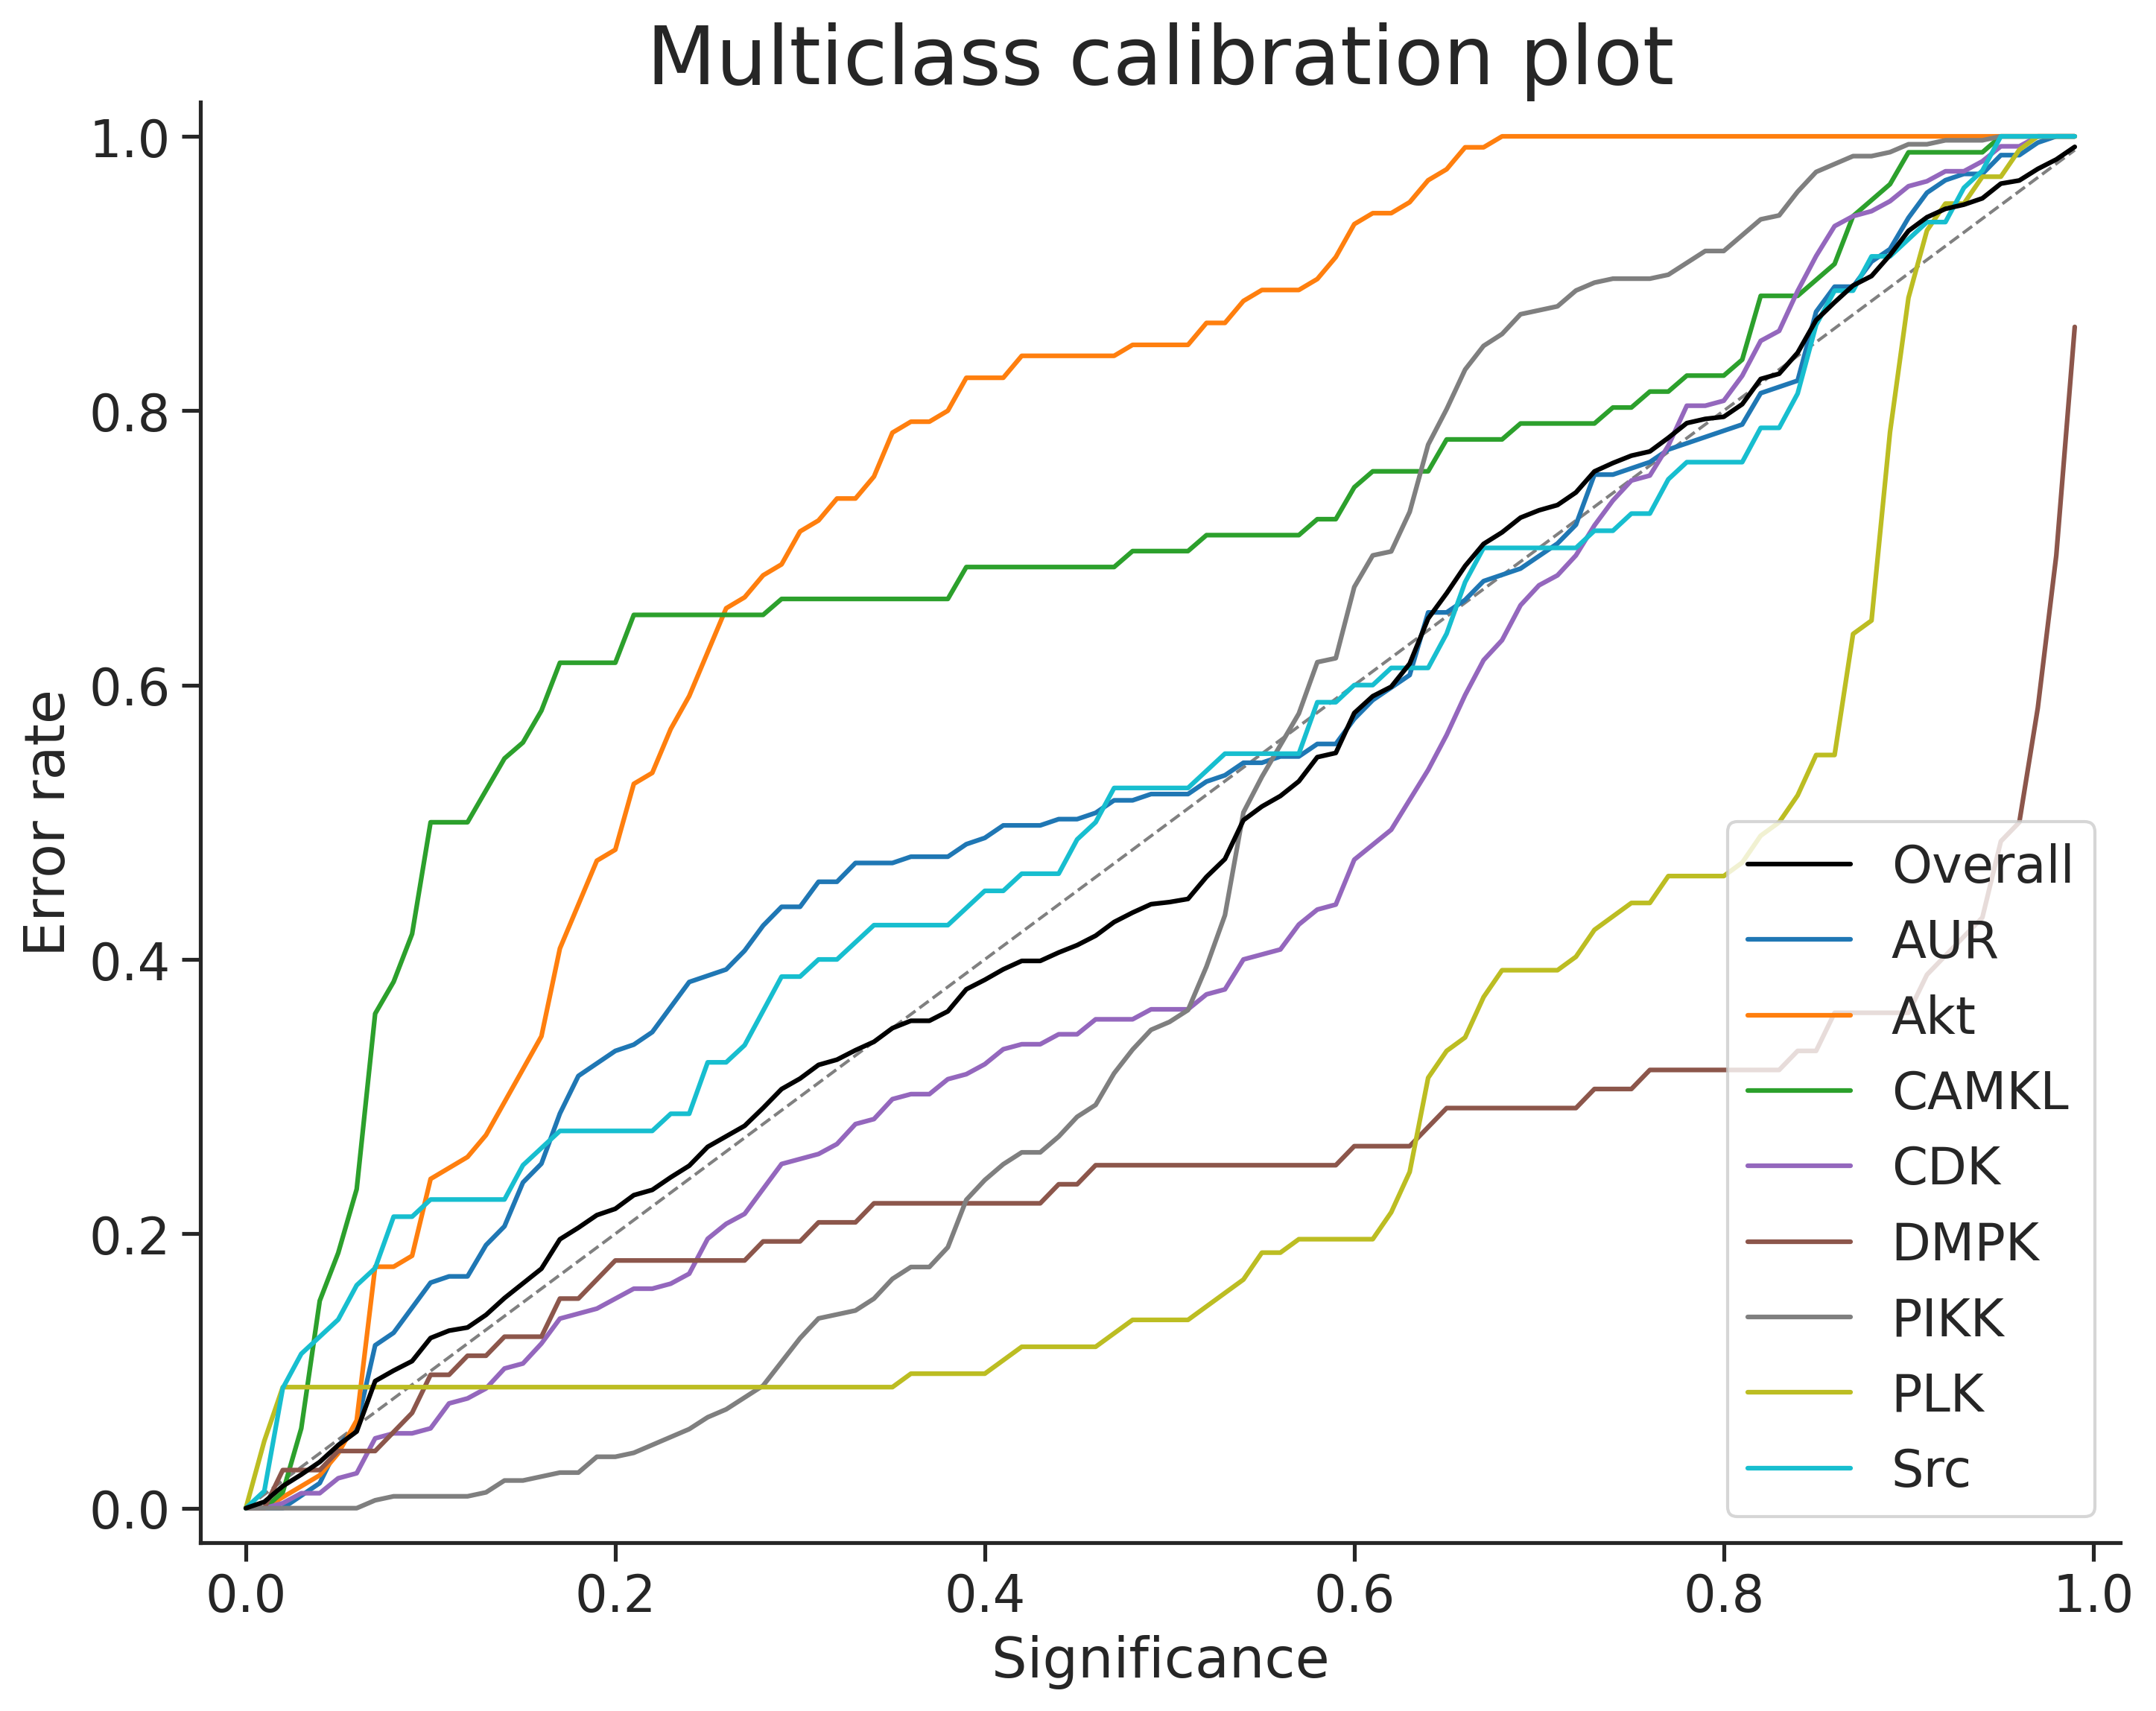

In [198]:
import matplotlib.pyplot as plt
from conf_eval import plot

# Define the number of classes
num_classes = len(class_labels)

# Get a color map with enough colors
colors = plt.cm.get_cmap('tab10', num_classes)

# Now plot using the custom color map
multiclass_fig = plot.plot_calibration_clf(encoded_true_labels, 
                                           p_values, 
                                           title='Multiclass calibration plot', 
                                           labels=class_labels,
                                           cm=colors)  # Pass the colors to the plot

plt.show()  # Show the plot

In [199]:
class_labels = ['AUR', 'Akt', 'CAMKL', 'CDK', 'DMPK', 'PIKK', 'PLK', 'Src']
custom_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f']


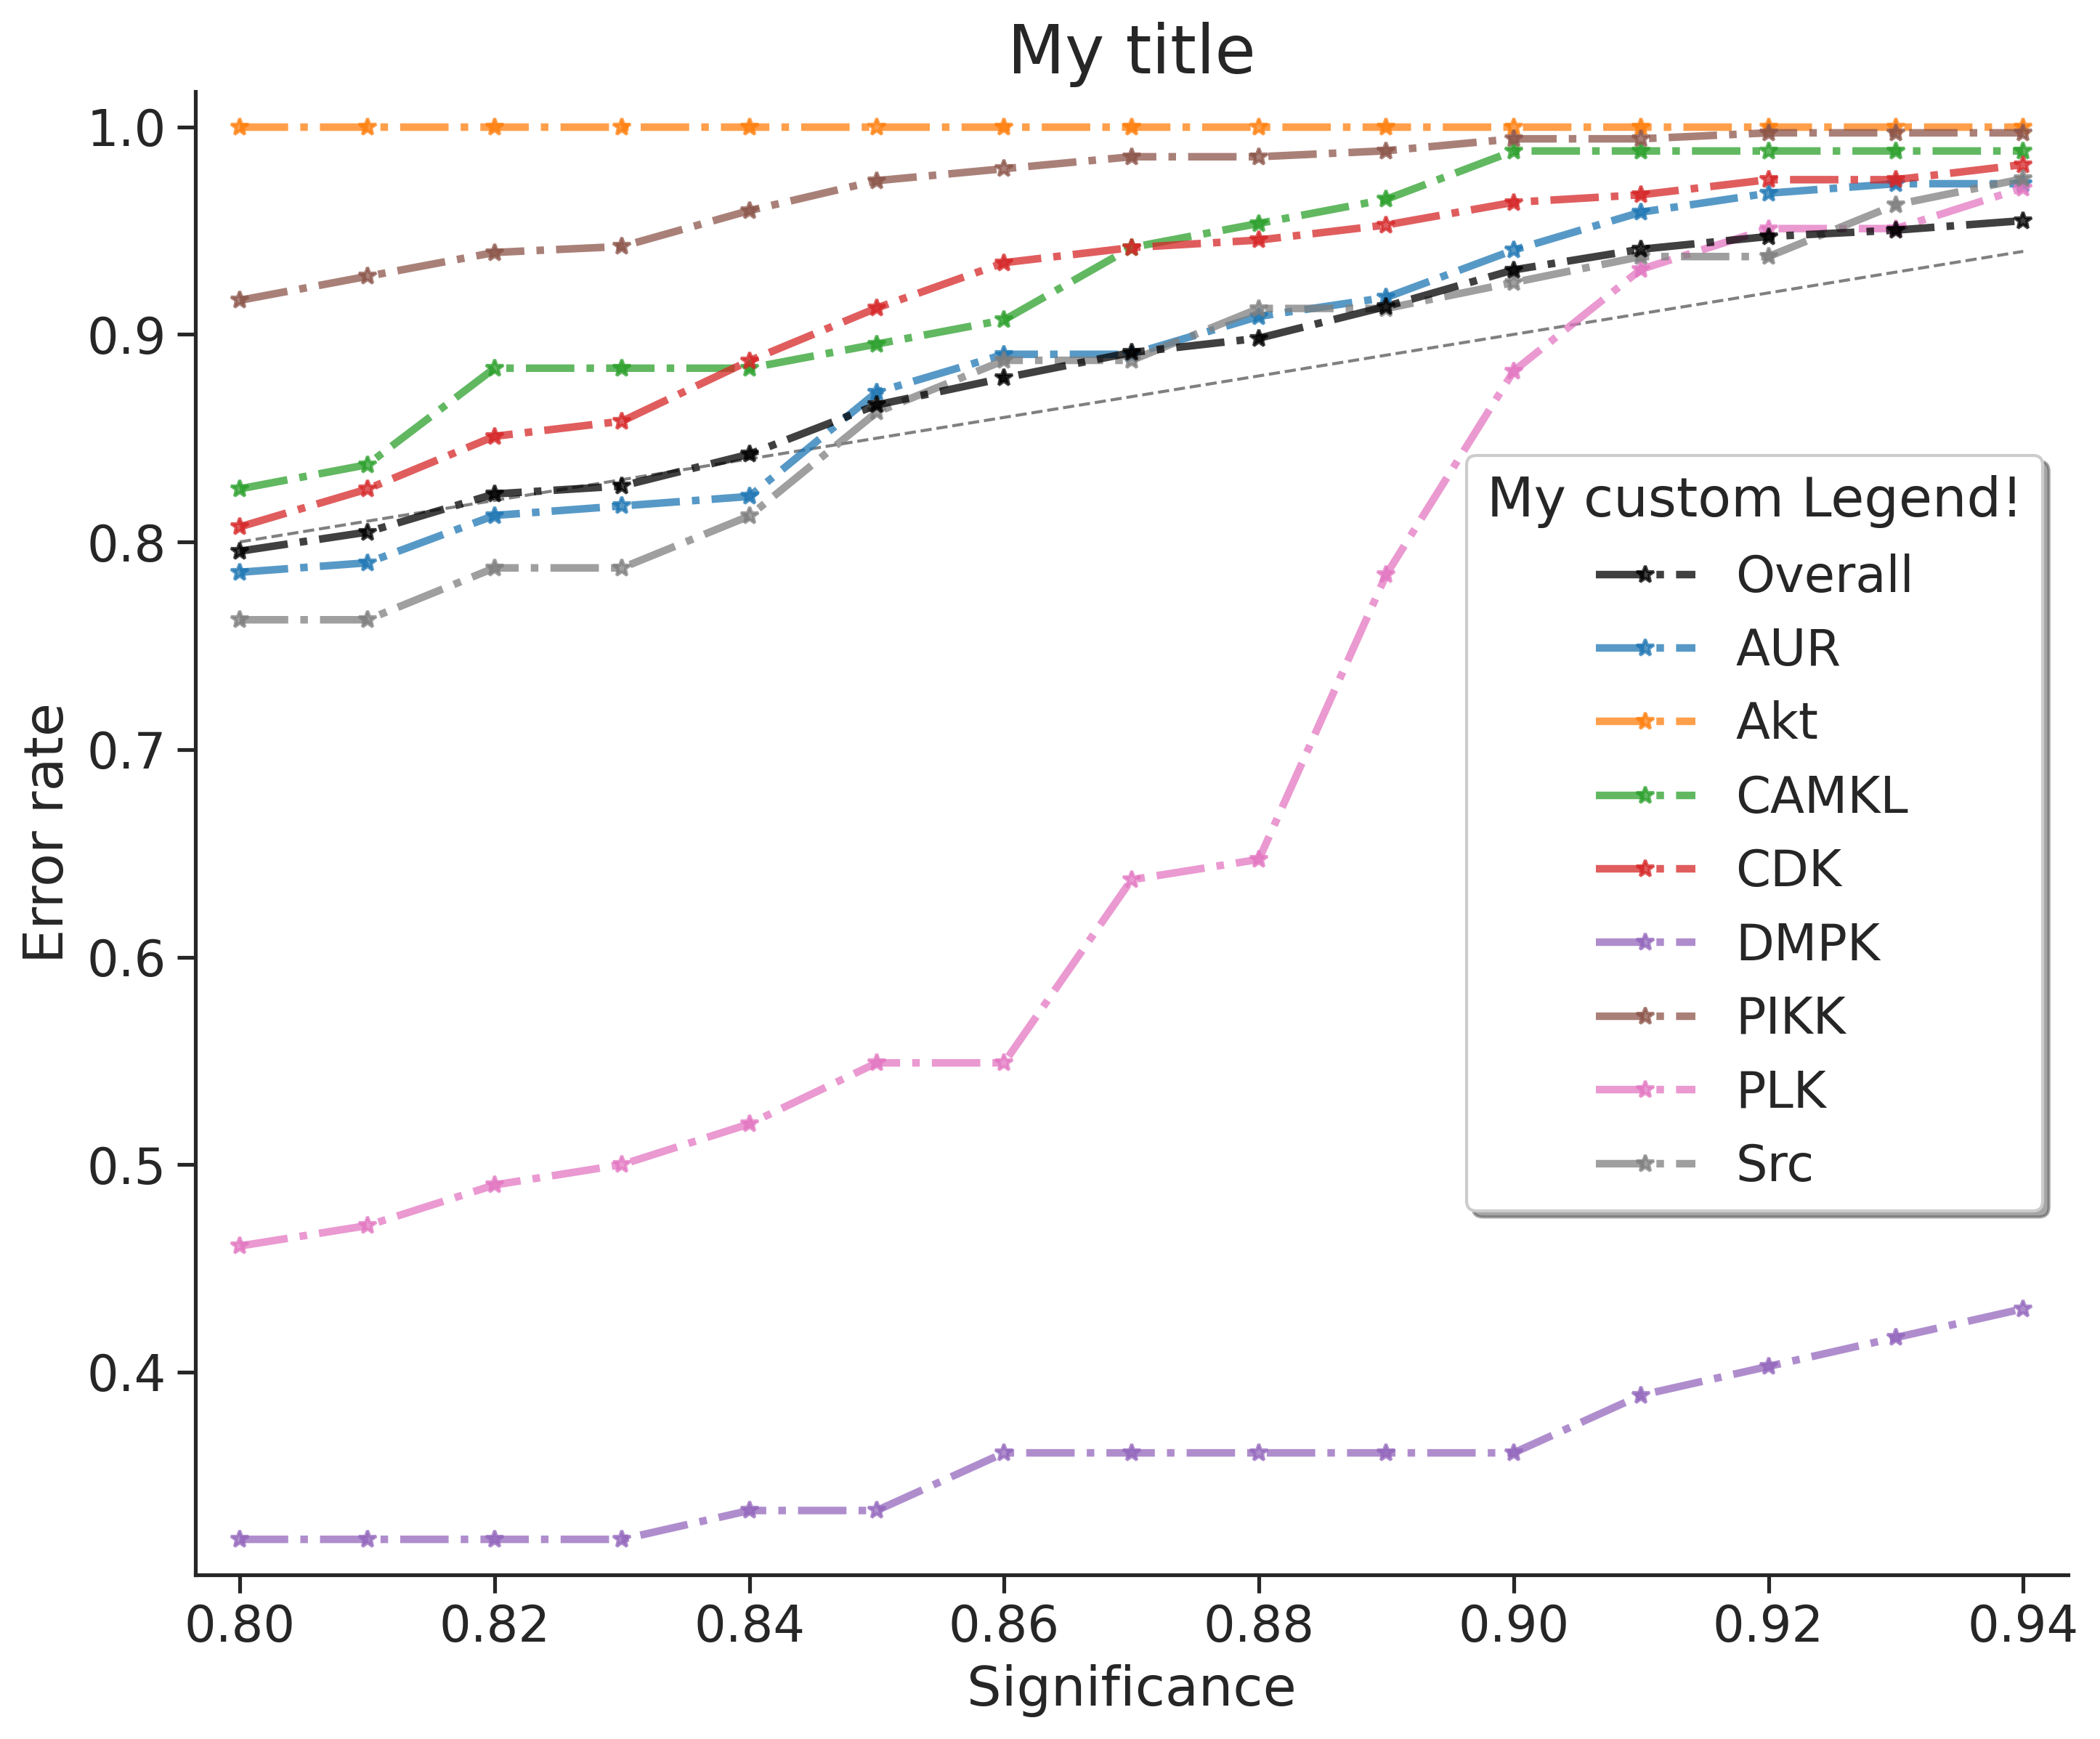

In [200]:
import matplotlib.pyplot as plt
import numpy as np
from conf_eval import plot

# Define a list of 8 custom colors

# Generate the calibration plot with custom colors
the_fig = plot.plot_calibration_clf(encoded_true_labels,
                                    p_values,
                                    sign_vals=np.arange(0.8, 0.95, 0.01),
                                    chart_padding=0.025,
                                    labels=class_labels,
                                    cm=custom_colors,  # Pass the list of custom colors
                                    **line_args)

# Get the axes to make customizations on
axes = the_fig.axes[0]

# Set a custom title
axes.set_title('My title', fontsize=22)

# Add a new (custom) legend
axes.legend(shadow=True, title='My custom Legend!')

# Show the plot
plt.show()

In [201]:
print(np.unique(encoded_true_labels))  # Check the unique values in the labels

[0 1 2 3 4 5 6 7]


In [202]:
# Example with 8 distinct colors for 8 classes
# Ensure that encoded_true_labels has values between 0 and 7
unique_labels = np.unique(encoded_true_labels)
print(f"Unique labels: {unique_labels}")
print(f"Number of unique labels: {len(unique_labels)}")

# Check if the length of the colors matches the number of unique labels
if len(unique_labels) != len(colors):
    raise ValueError(f"Number of colors ({len(colors)}) does not match number of unique labels ({len(unique_labels)})")

markers = ['o', 'x', 's', 'p', '*', 'D', 'v', '^']  # 8 distinct markers, one for each class
font_args = None  # Example of font arguments

# Ensure that the number of labels and markers match the number of classes
sizes = 100  # Use a single size for all points

p0p1 = plot.plot_pvalues(encoded_true_labels,
                         p_values,
                         title='P0-P1 plot',
                         sizes=sizes,
                         cm=custom_colors,  # Pass the list of custom colors
                         markers=markers,
                         labels=class_labels,  # Ensure class_labels corresponds to 8 classes
                         fontargs=font_args,
                         **kwargs)

Unique labels: [0 1 2 3 4 5 6 7]
Number of unique labels: 8


TypeError: object of type 'ListedColormap' has no len()

In [114]:
# Check shapes of encoded_true_labels and p_values
print(f"encoded_true_labels shape: {encoded_true_labels.shape}")
print(f"p_values shape: {p_values.shape}")

encoded_true_labels shape: (1306,)
p_values shape: (1306, 8)


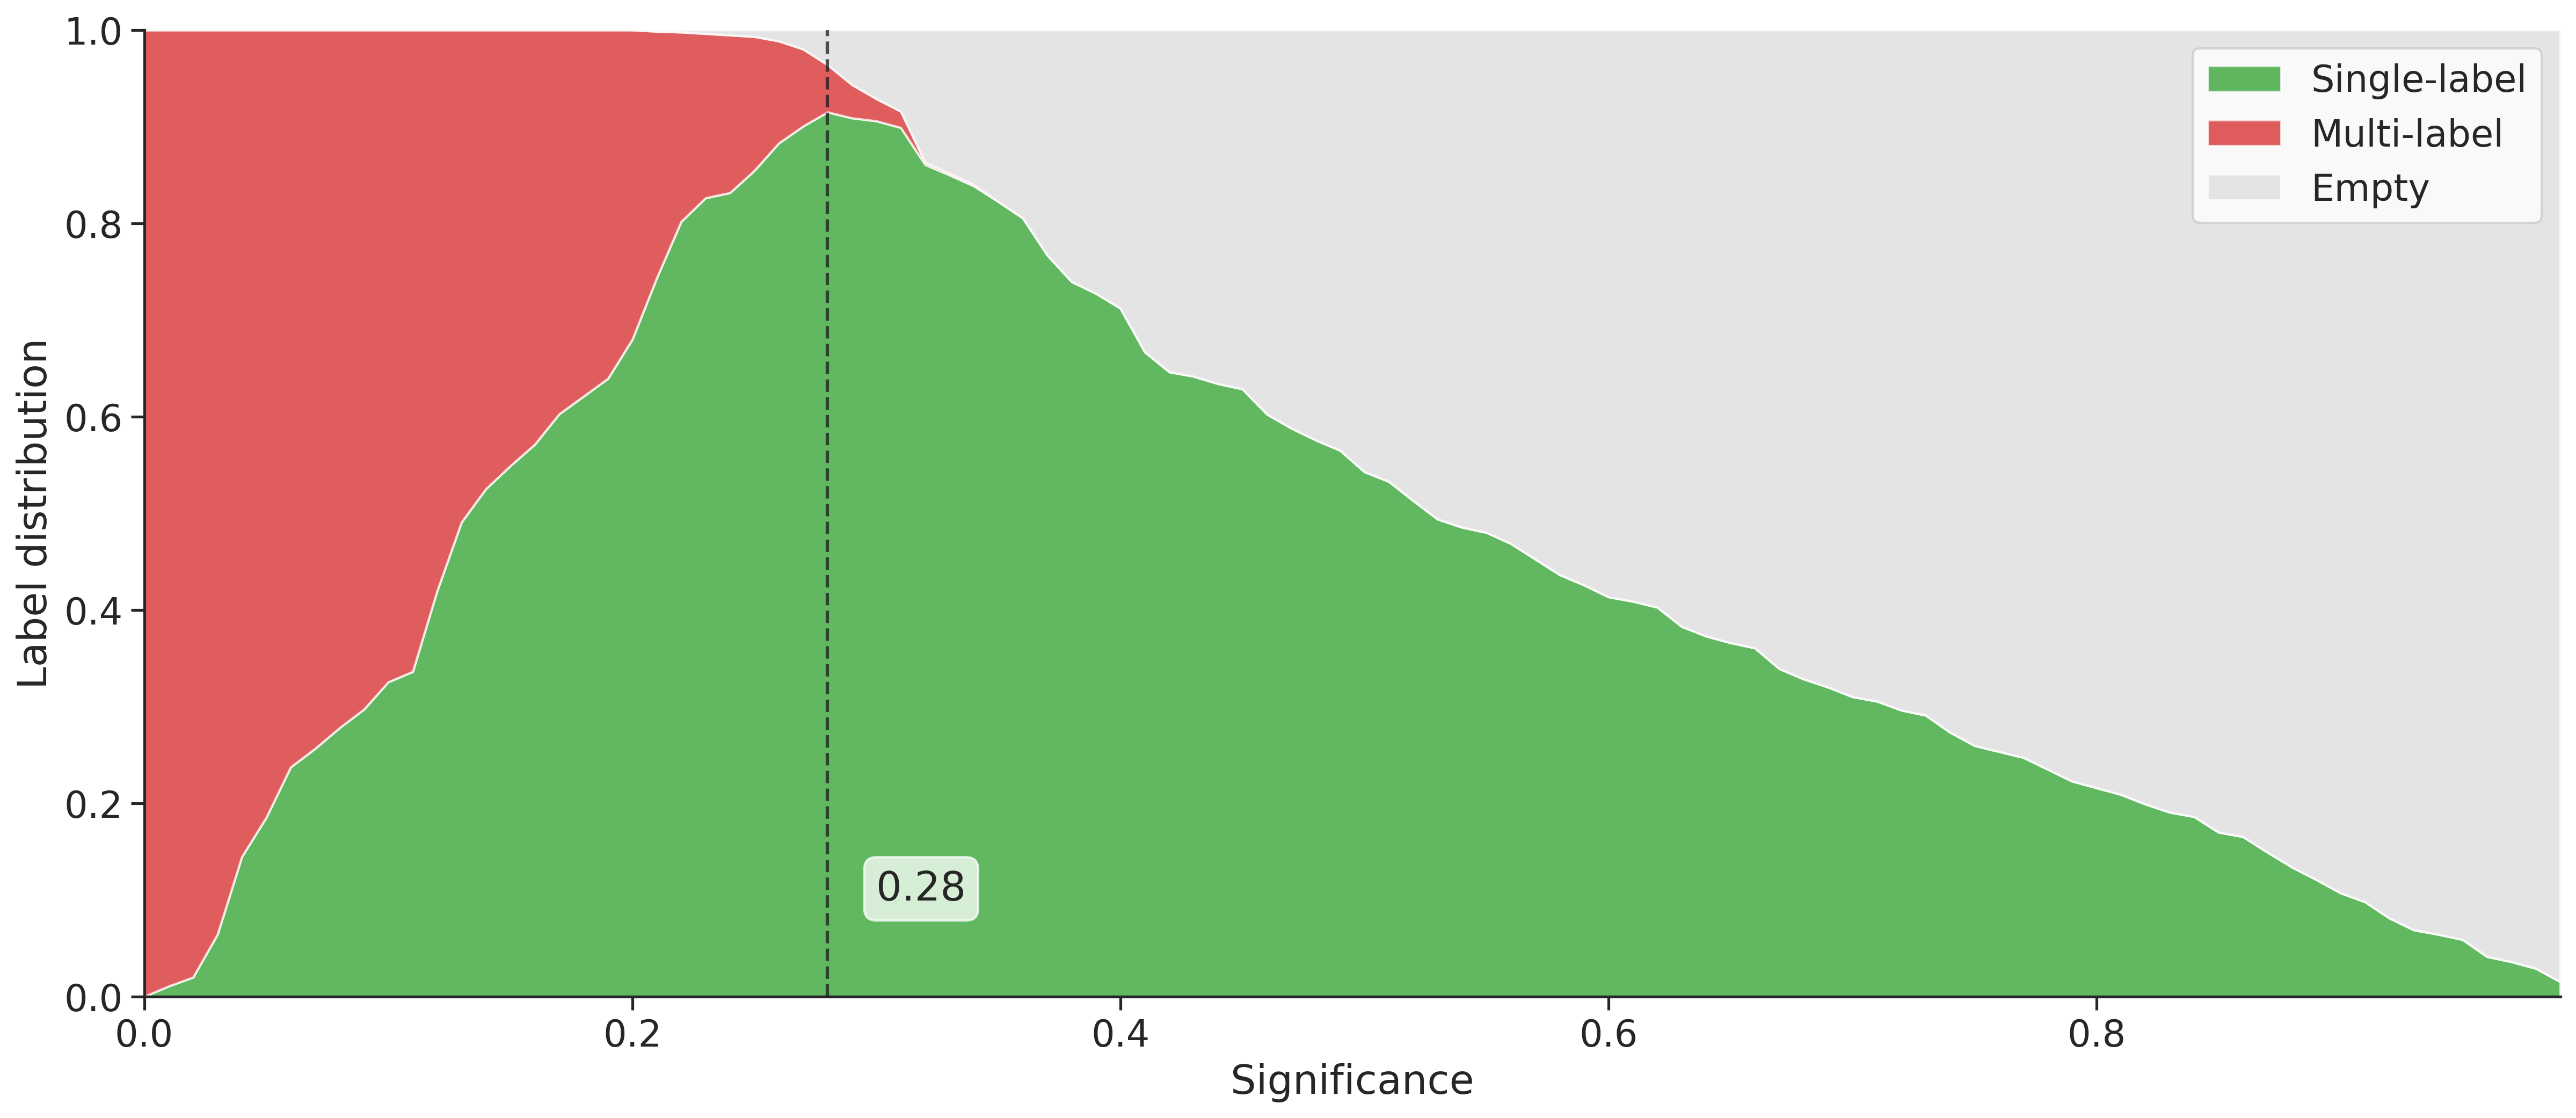

In [131]:

my_fig = plt.figure(figsize=(15,6))
ax = my_fig.add_axes([0,0,1,1])
custom_args = {'alpha': 0.75}
fig = plot.plot_label_distribution(y_true=encoded_true_labels,p_values=p_values, tight_layout=False, ax=ax, **custom_args)
# my_fig.savefig('area-plot.png',bbox_inches='tight')

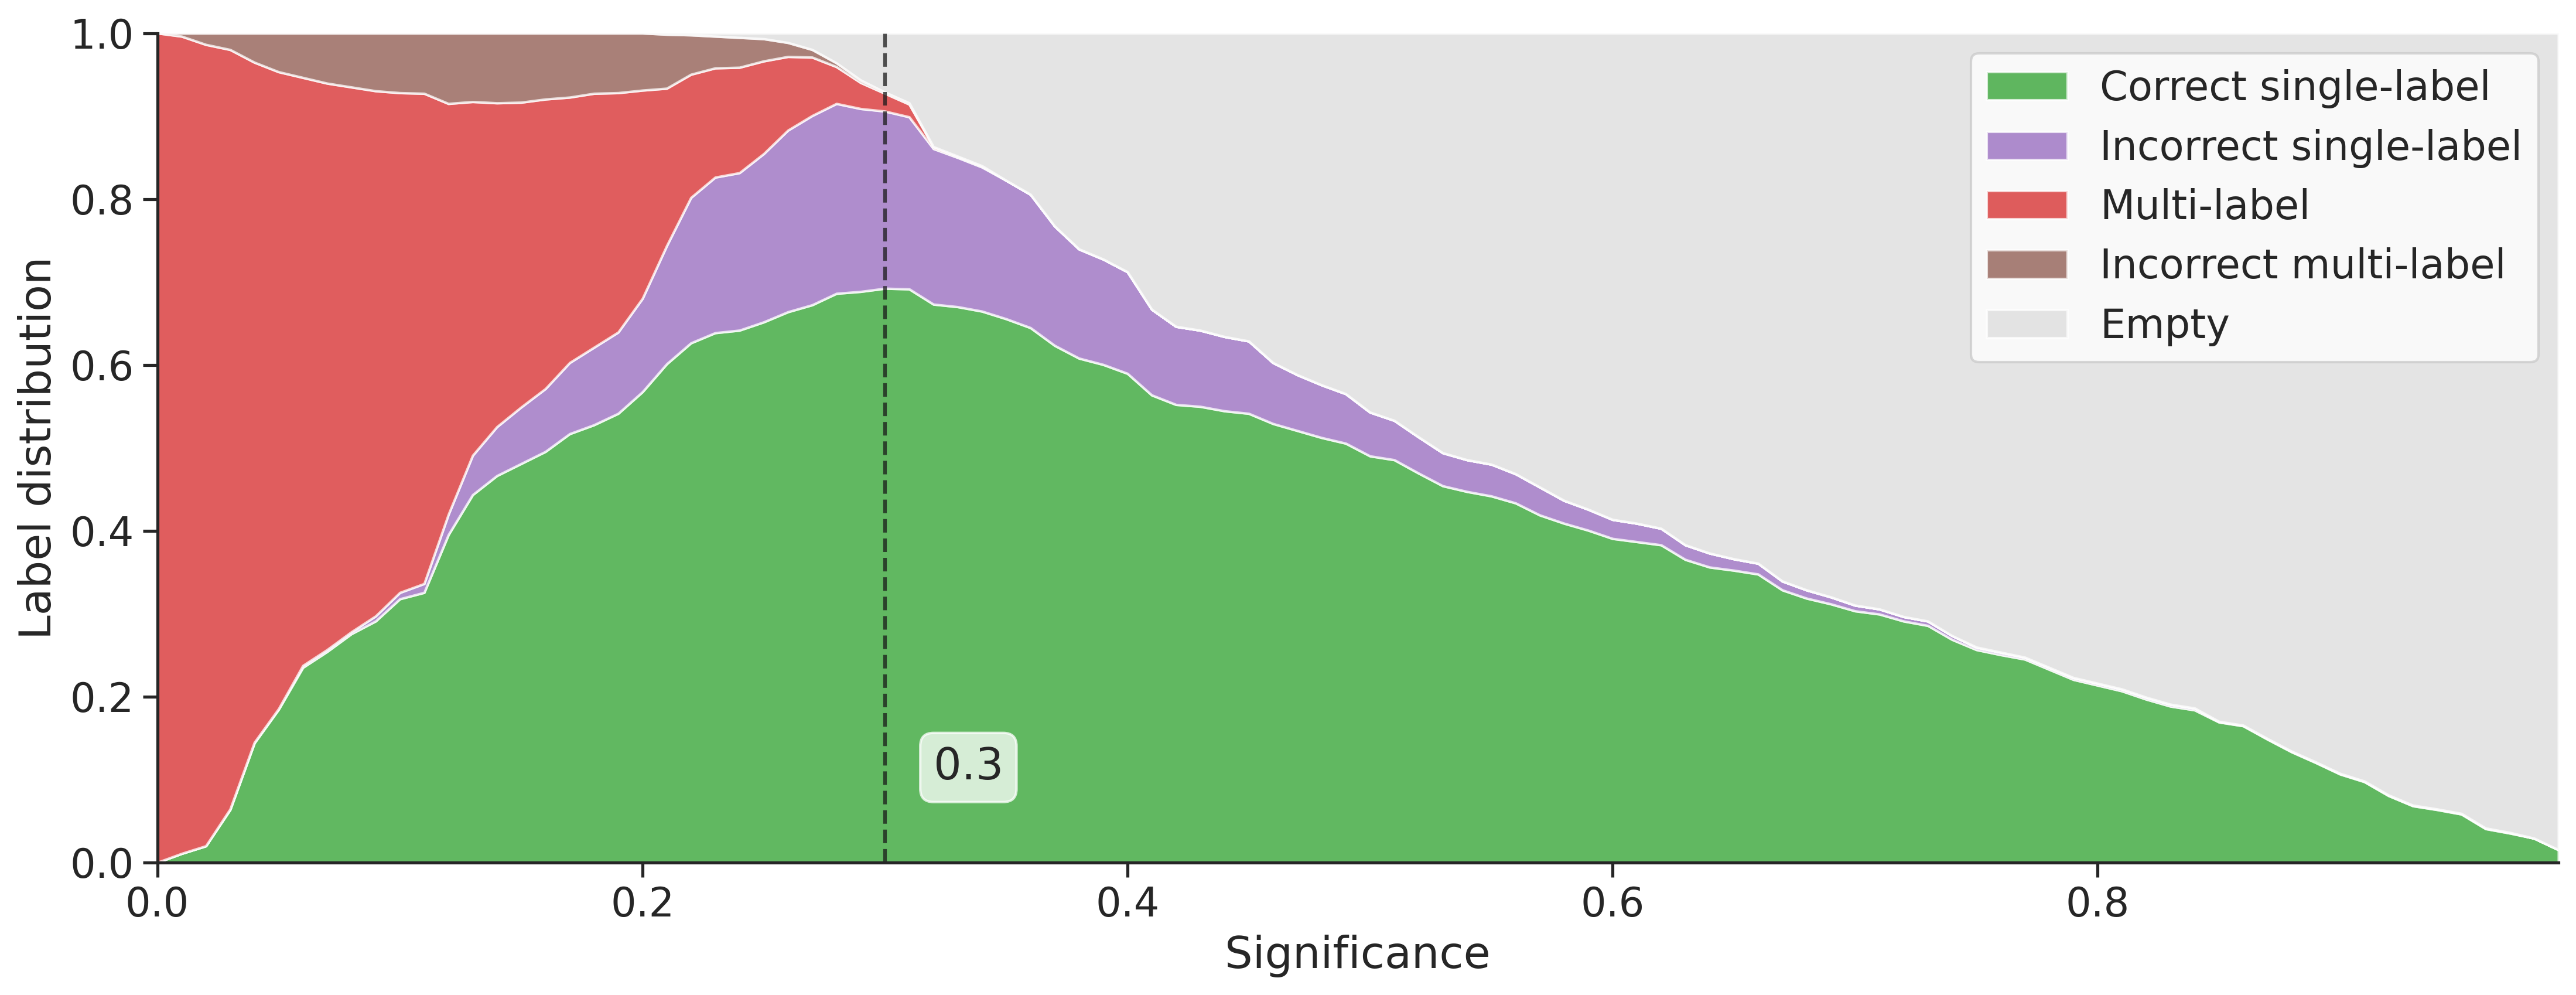

In [132]:
fig = plot.plot_label_distribution(y_true=encoded_true_labels,
                                   p_values=p_values,
                                   figsize=(15,6),
                                   display_incorrect=True,
                                   **custom_args)

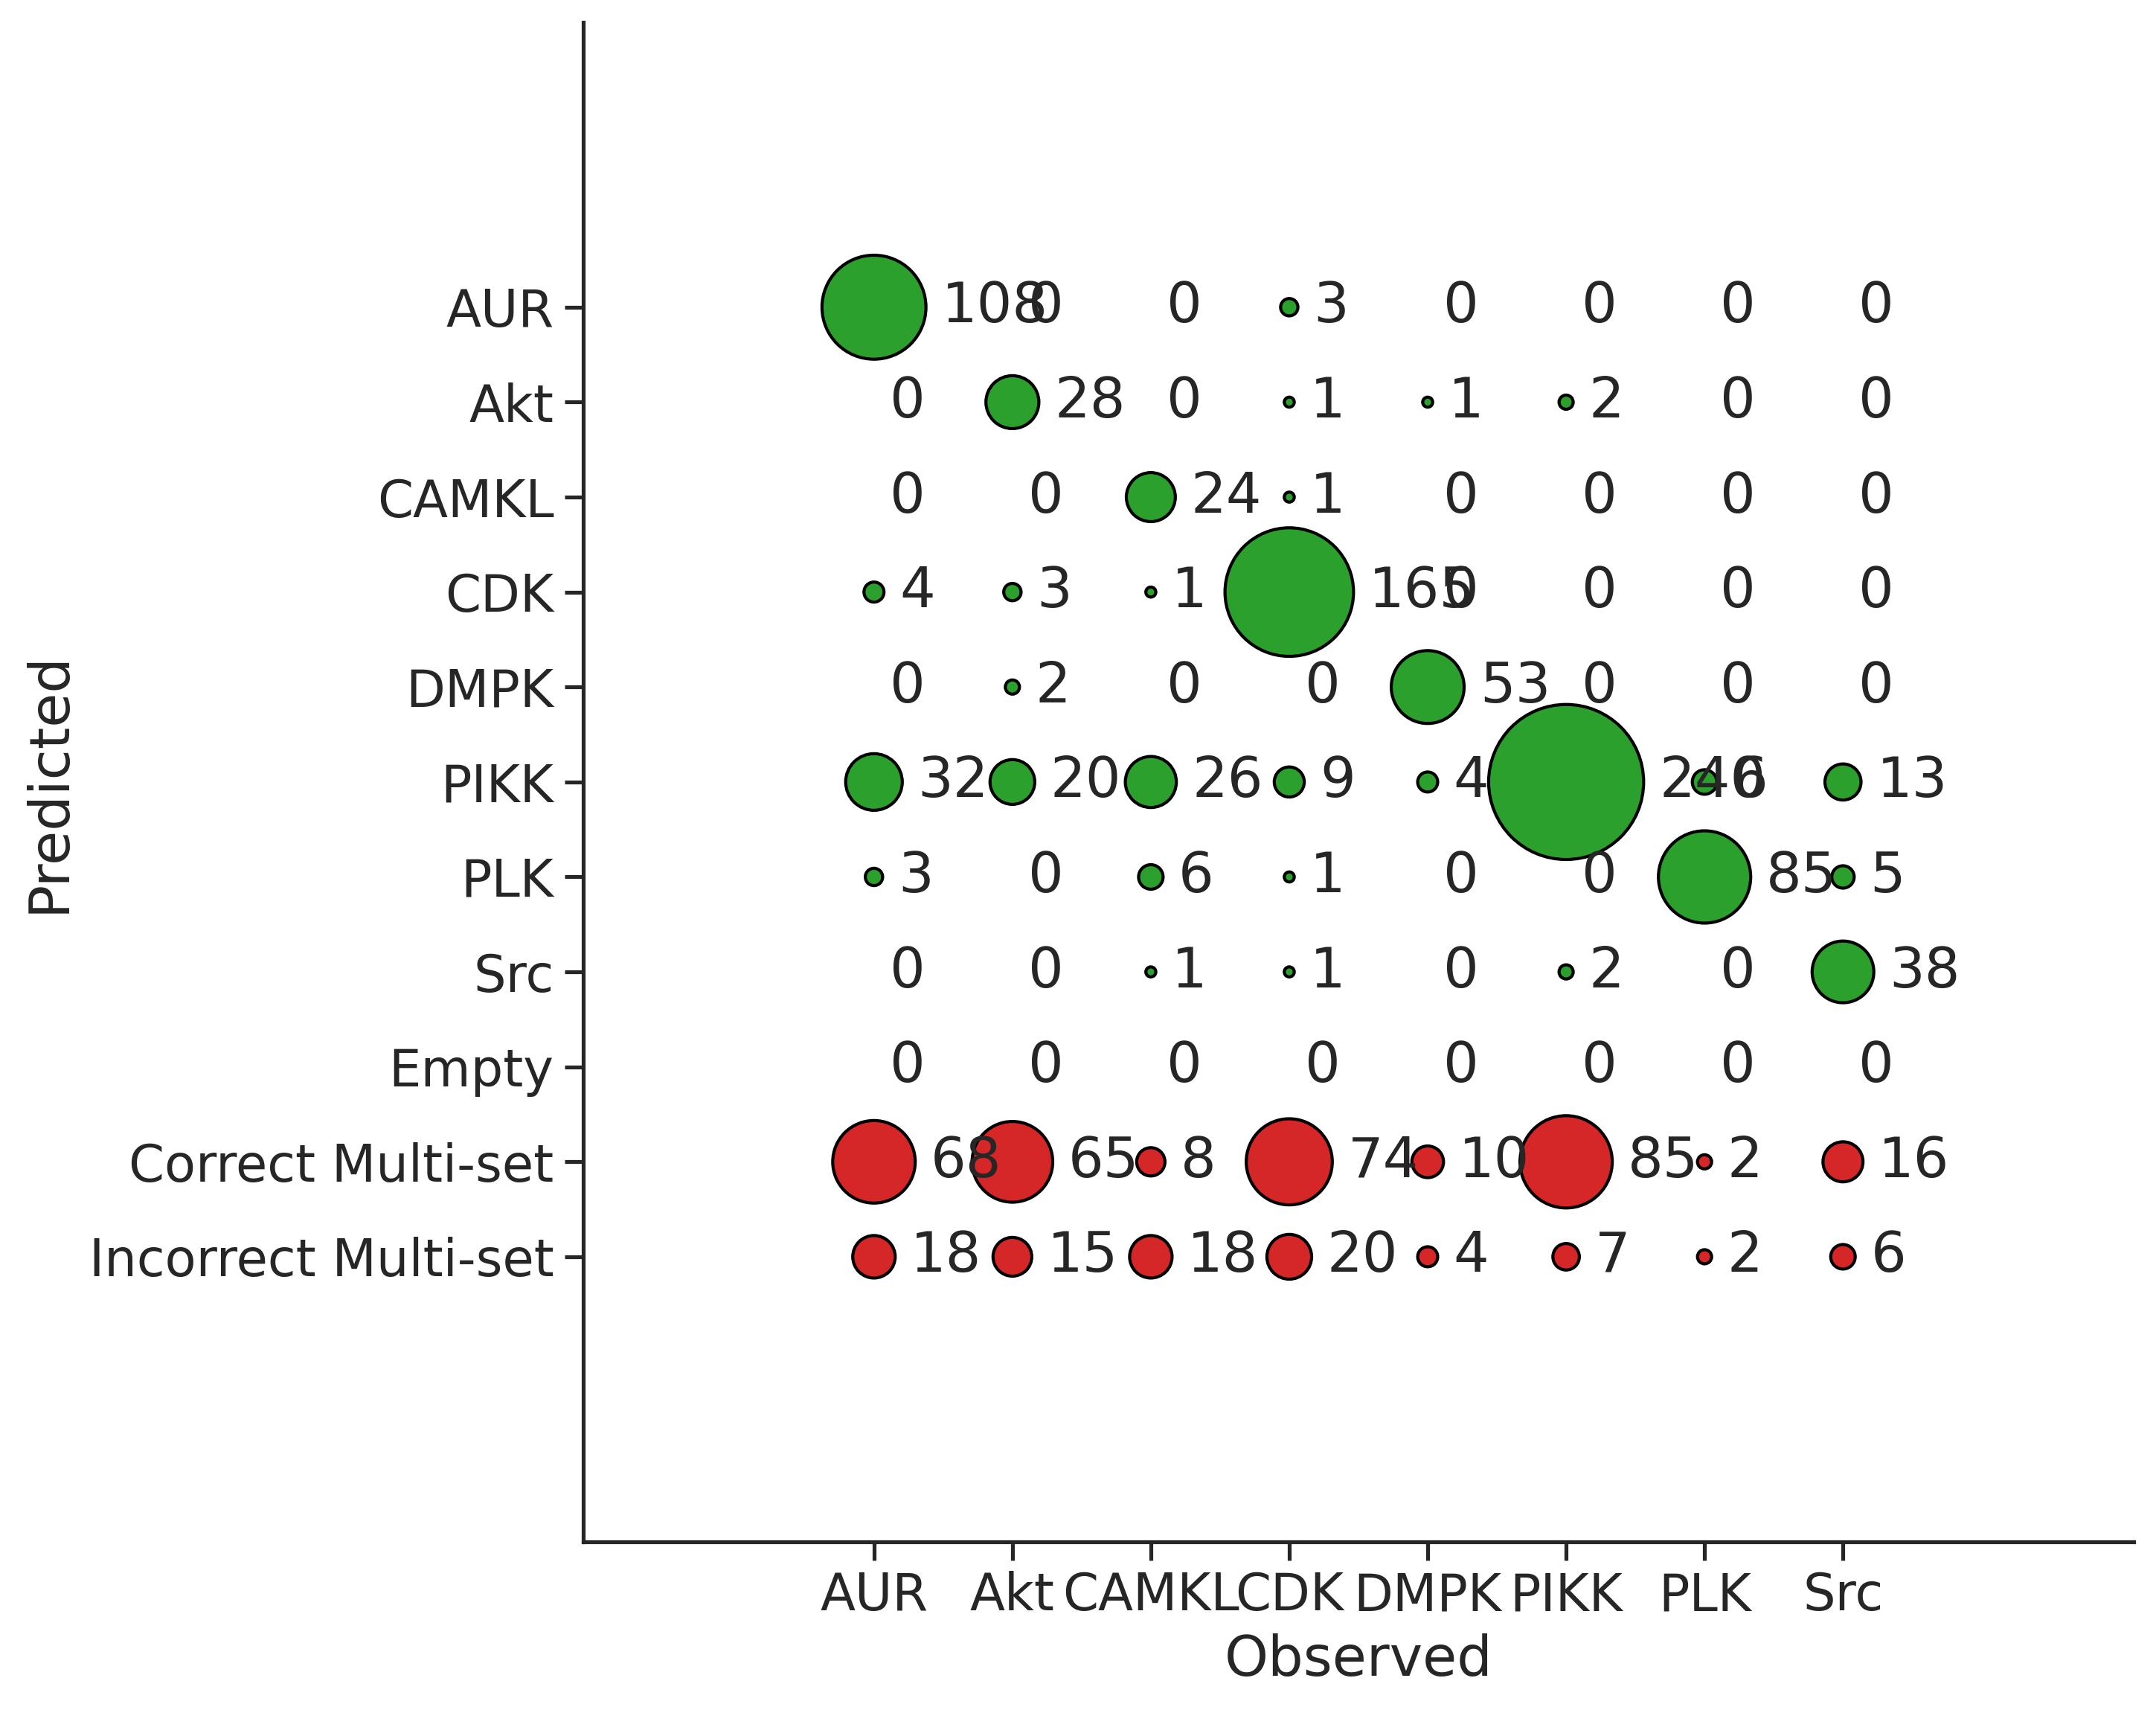

In [149]:
bubble_plot = plot.plot_confusion_matrix_bubbles(confusion_matrix=CM)


/home/jovyan/.local/lib/python3.10/site-packages/conf_eval/plot/_classification.py:1044: UserWarning: color_scheme='class_labels' not recognized, falling back to None
  warnings.warn('color_scheme=\'{}\' not recognized, falling back to None'.format(color_scheme))


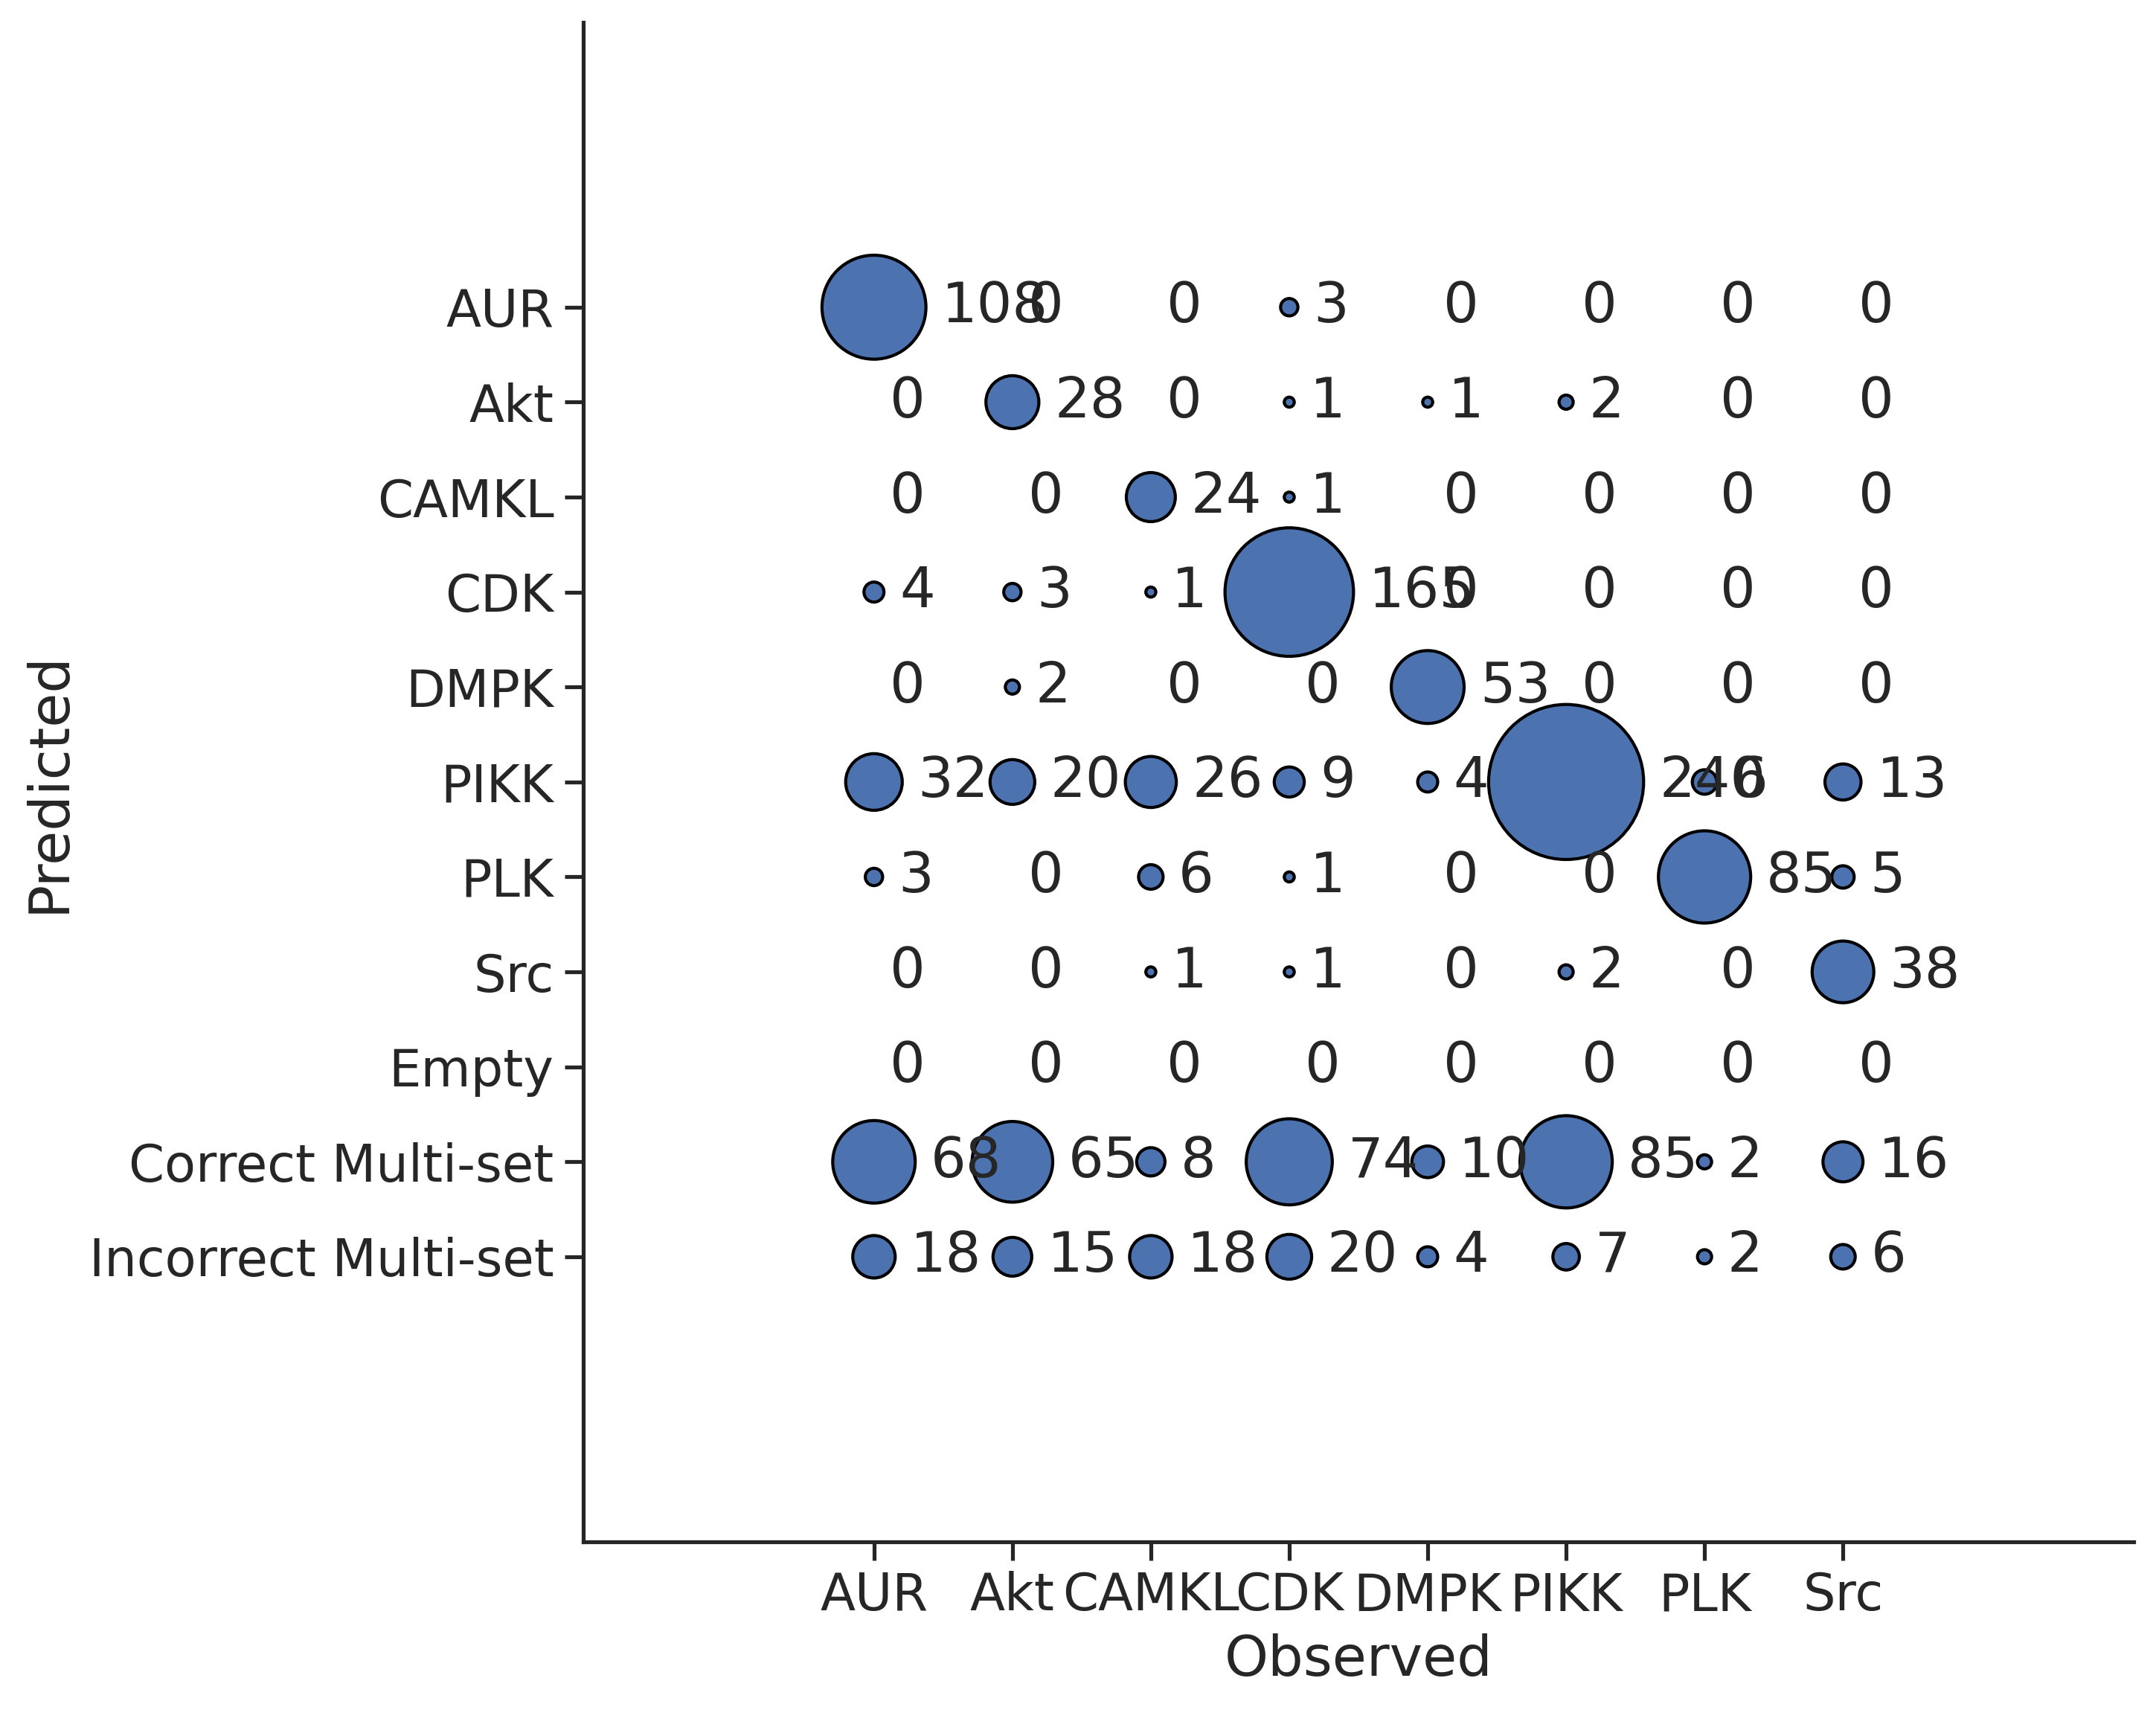

In [150]:
bubble_plot_label = plot.plot_confusion_matrix_bubbles(confusion_matrix=CM, color_scheme='class_labels')


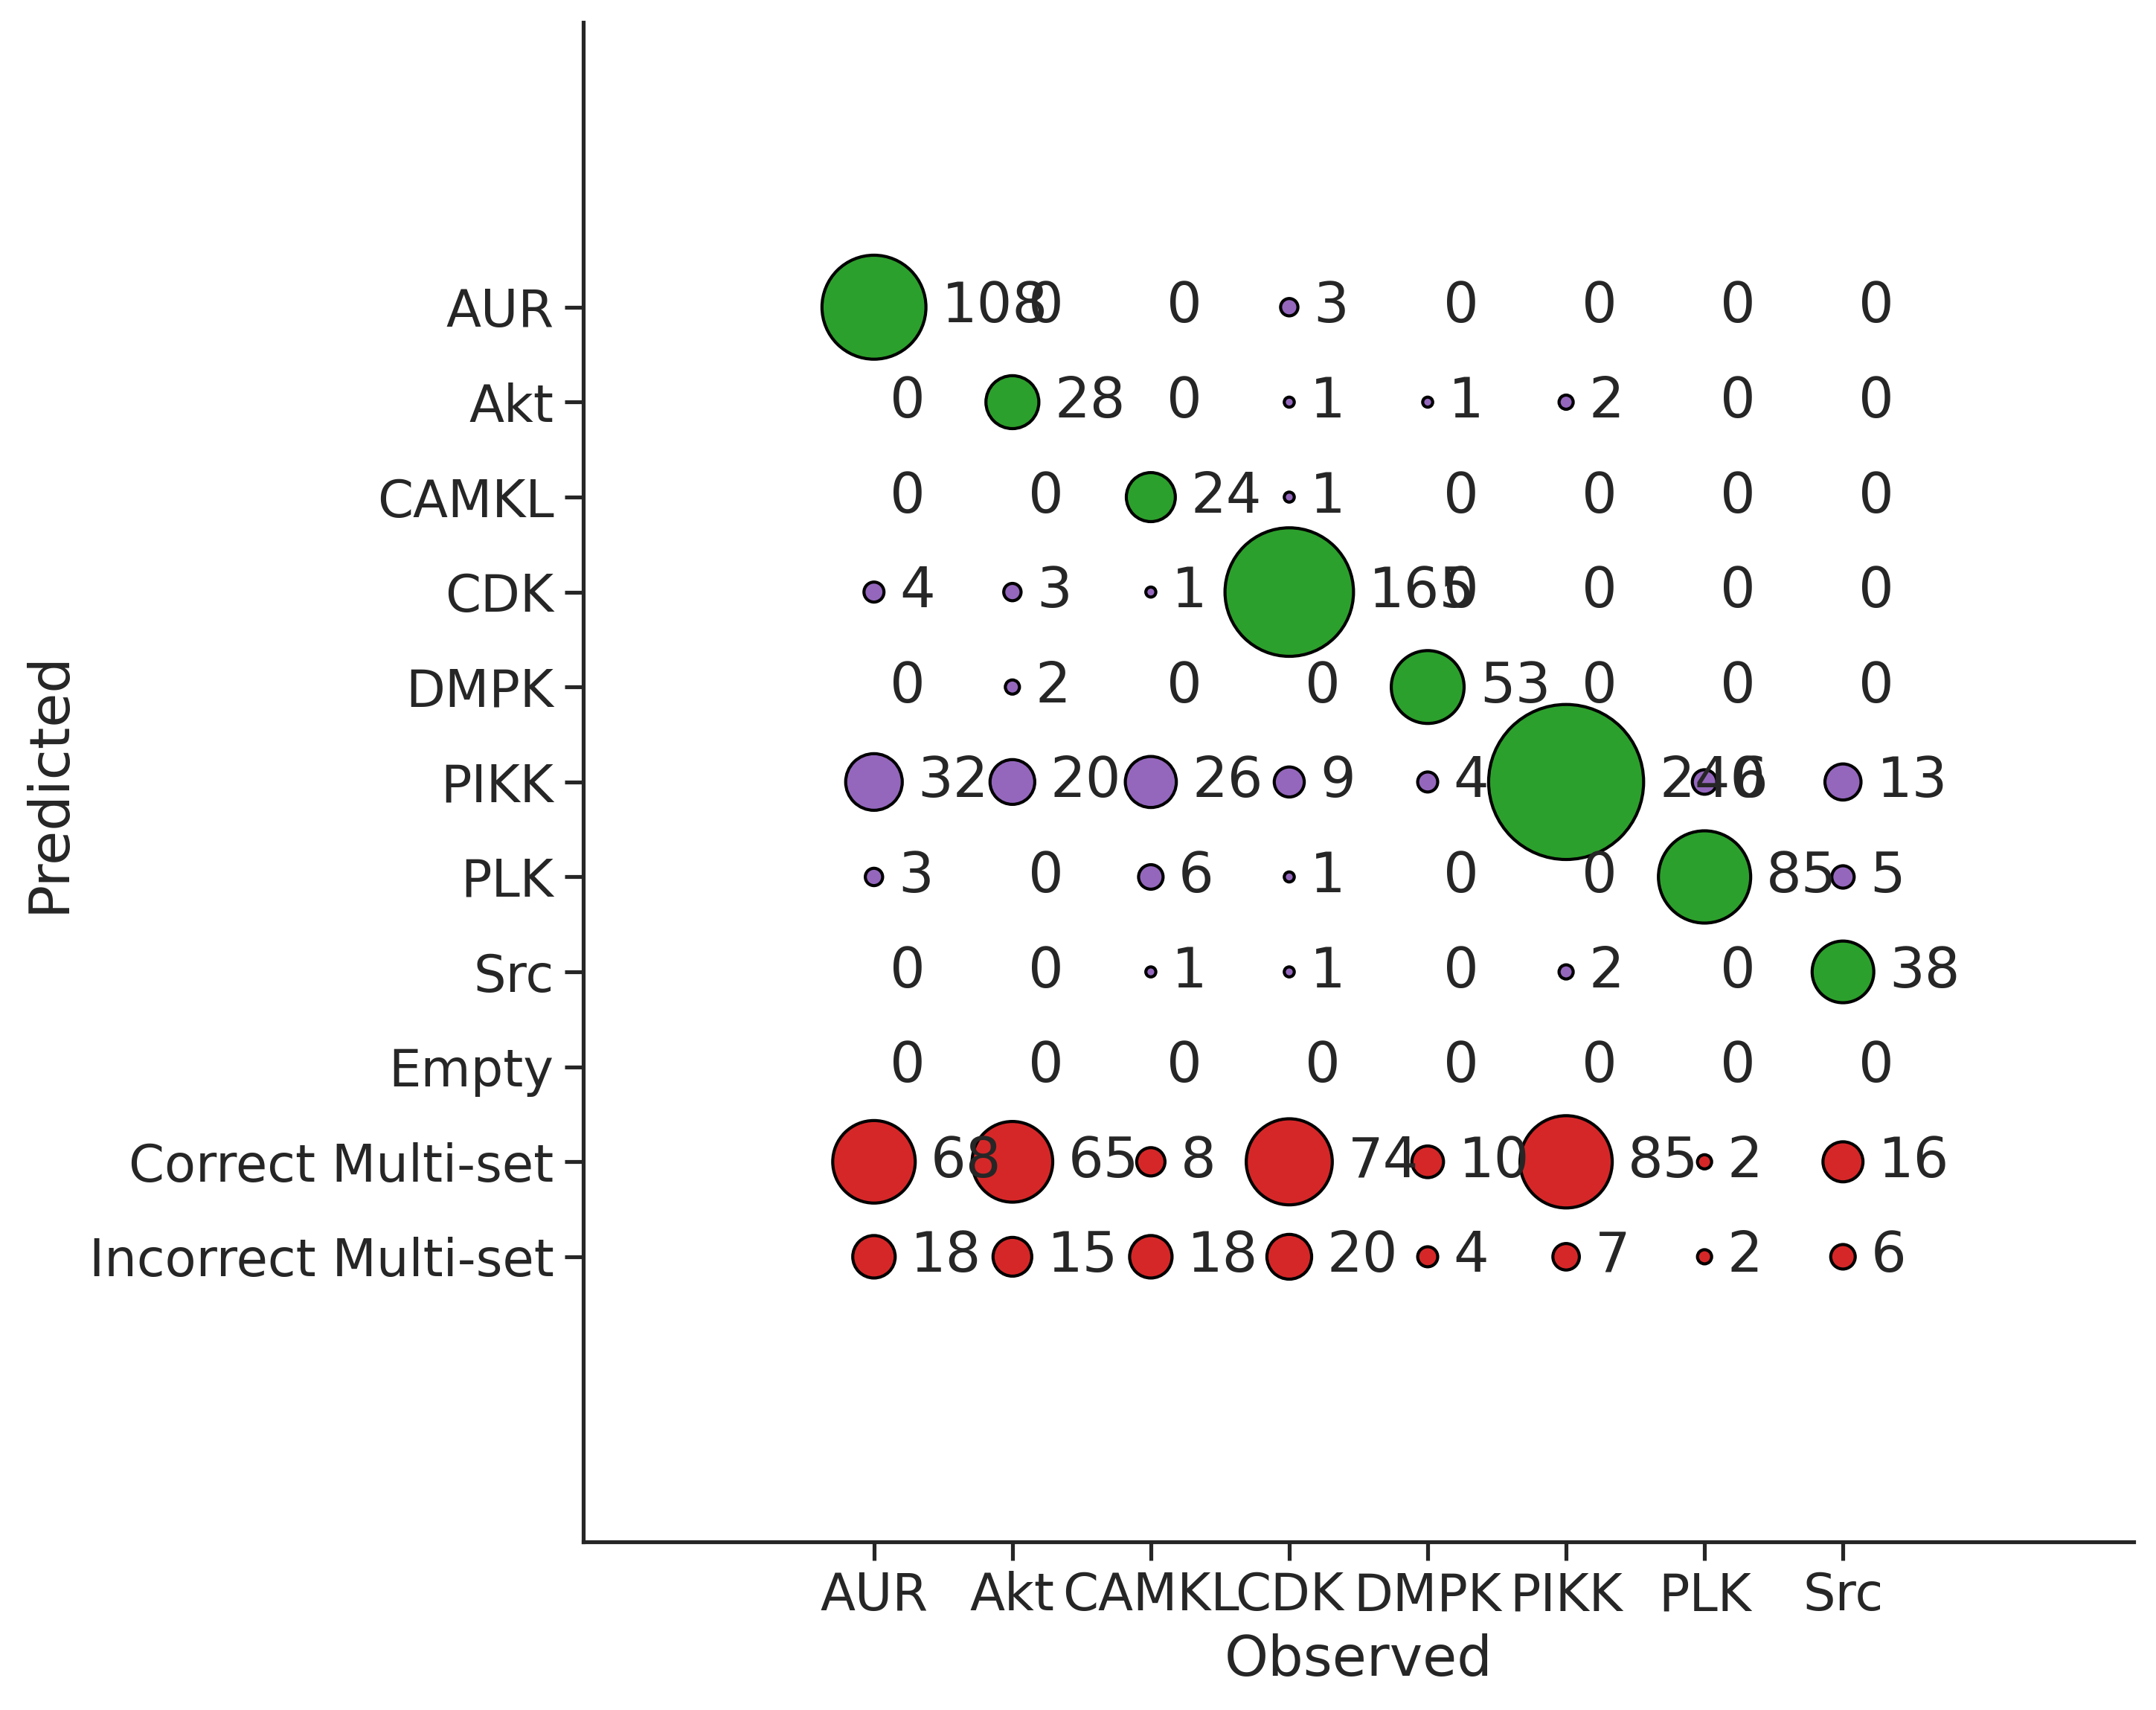

In [151]:
bubble_plot_label = plot.plot_confusion_matrix_bubbles(confusion_matrix=CM, 
                                                           color_scheme='full')

TypeError: confusion_matrix() got an unexpected keyword argument 'cm'

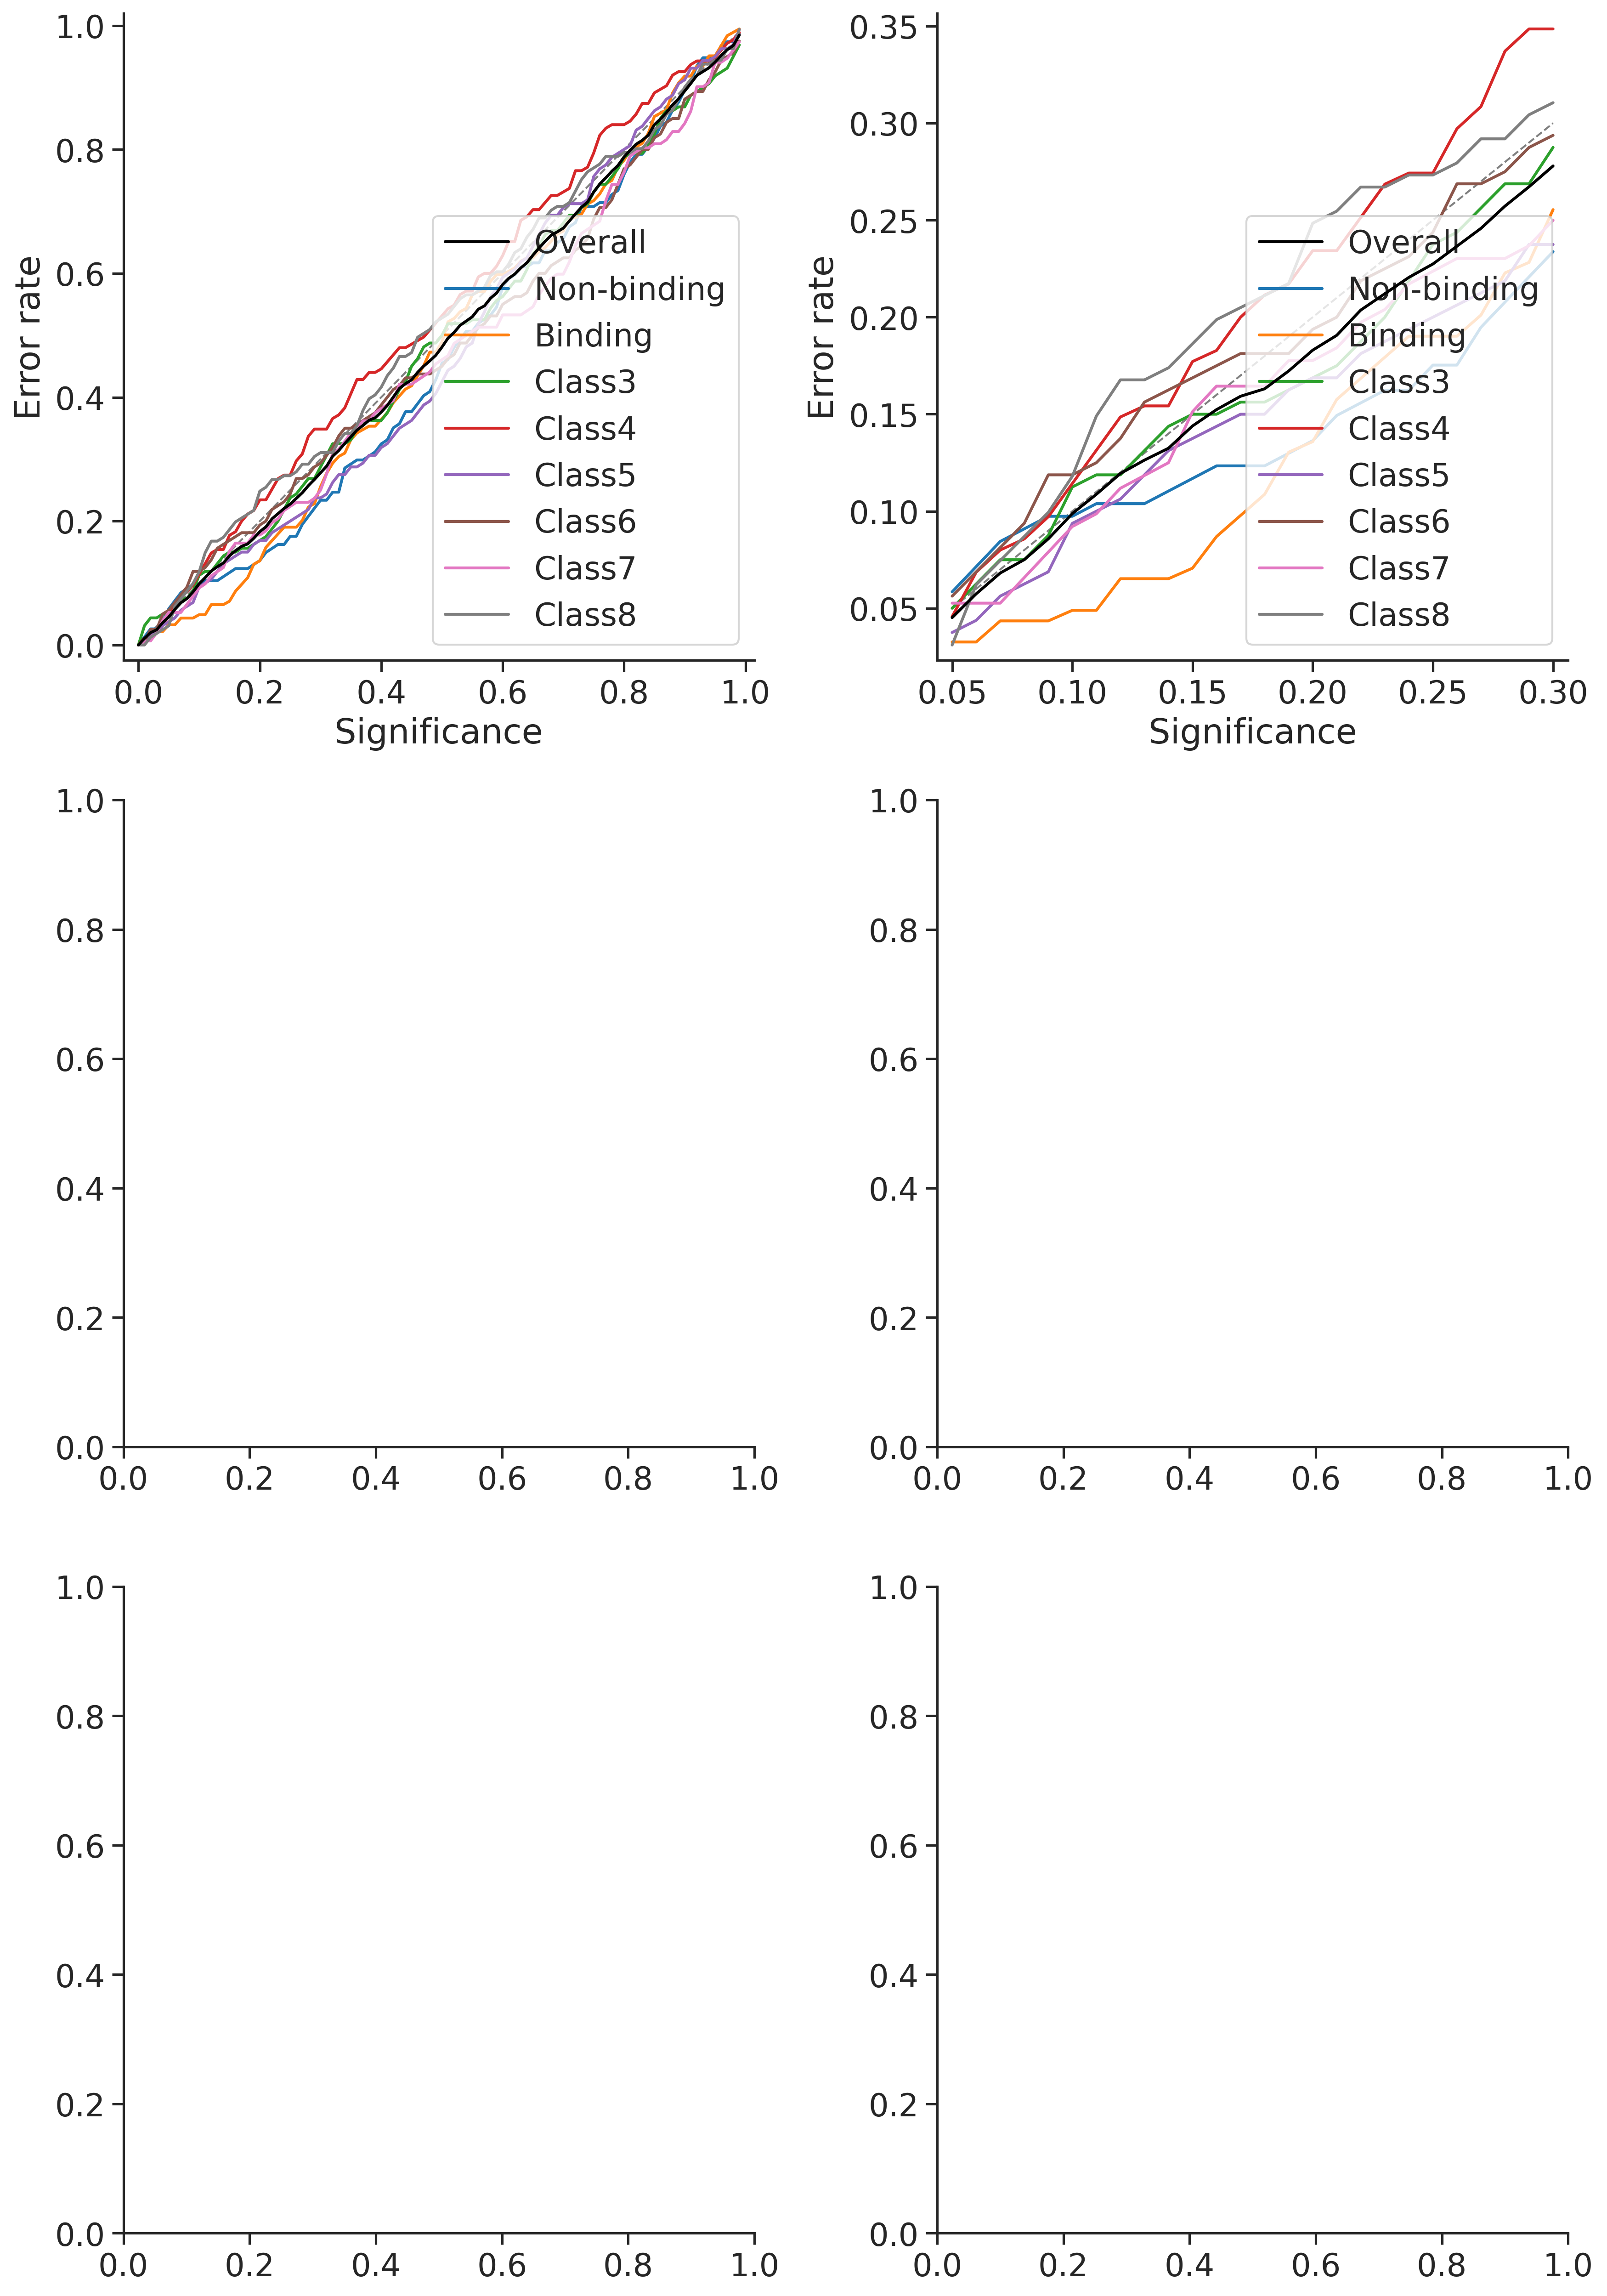

In [155]:

import matplotlib.pyplot as plt
import numpy as np

# Example data
encoded_true_labels = np.random.randint(0, 8, size=1306)  # Random true labels
p_values = np.random.rand(1306, 8)  # Random predicted probabilities

# Create subplots
fig, axes = plt.subplots(3, 2, figsize=(12, 17))

# Ensure class_labels matches number of unique labels in p_values
class_labels = ['Non-binding', 'Binding', 'Class3', 'Class4', 'Class5', 'Class6', 'Class7', 'Class8']

# Calibration plot
plot.plot_calibration_clf(encoded_true_labels, p_values, ax=axes[0, 0], labels=class_labels, cm=custom_colors)

# 70-95% confidence only
plot.plot_calibration_clf(encoded_true_labels, p_values, ax=axes[0, 1], sign_vals=np.arange(0.05, 0.31, 0.01), chart_padding=.025, labels=class_labels, cm=custom_colors)

# Bubble plot
plot.plot_confusion_matrix_bubbles(metrics.confusion_matrix(encoded_true_labels, p_values, .2, labels=class_labels,cm=custom_colors), title="Bubble plot (sign=0.2)", ax=axes[1, 0])

# Normalized heatmap
plot.plot_confusion_matrix_heatmap(metrics.confusion_matrix(encoded_true_labels, p_values, .2, labels=class_labels, normalize_per_class=True), vmin=0, vmax=1, ax=axes[1, 1], title="Normalized heatmap (sign=0.2)")

# Label distribution
plot.plot_label_distribution(y_true=encoded_true_labels, p_values=p_values, ax=axes[2, 0], cm=custom_colors)

# Label distribution with incorrect labels
plot.plot_label_distribution(y_true=encoded_true_labels, p_values=p_values, ax=axes[2, 1], display_incorrect=True, title='Label distribution',cm=custom_colors)

# Add main title
fig.suptitle('Metrics plots', fontsize=20)

# Adjust layout
fig.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()

## Mondrian

In [16]:
from crepes.extras import margin, DifficultyEstimator, MondrianCategorizer

'To control the error level across different groups of objects of interest, we may use so-called Mondrian conformal classifiers. \nA Mondrian conformal classifier if formed by providing a function or a MondrianCategorizer (defined in crepes.extras)\nas an additional argument, named mc, for the calibrate method.'

In [17]:
""" By default, the conformal classifiers obtained using WrapClassifier will compute non-conformity scores using
 the hinge function defined in crepes.extras. We could alternatively generate a conformal classifier using the 
 margin function, which we imported above:"""
svm_margin = WrapClassifier(wrapped_model.learner)

svm_margin.calibrate(X_cal, y_cal, nc=margin) # nc=margin we can define what function to use for non-conformity scores

display(svm_margin)

WrapClassifier(learner=SVC(C=1, probability=True), calibrated=True, predictor=ConformalClassifier(fitted=True, mondrian=False))

In [18]:
"""To control the error level across different groups of objects of interest, we may use so-called Mondrian conformal classifiers. 
A Mondrian conformal classifier if formed by providing a function or a MondrianCategorizer (defined in crepes.extras)
as an additional argument, named mc, for the calibrate method."""

svm_mond = WrapClassifier(wrapped_model.learner)
svm_mond.calibrate(X_cal, y_cal, mc=svm_mond.predict)

display(svm_mond)

WrapClassifier(learner=SVC(C=1, probability=True), calibrated=True, predictor=ConformalClassifier(fitted=True, mondrian=True))

In [35]:
prediction_sets_mond = svm_mond.predict_set(X_test)

display(prediction_sets_mond)

array([[1, 0, 0, 1, 0, 0, 0, 0],
       [1, 0, 1, 1, 0, 1, 0, 0],
       [0, 0, 0, 0, 0, 0, 1, 0],
       [0, 0, 0, 1, 0, 0, 0, 0],
       [1, 0, 0, 1, 0, 0, 0, 0],
       [0, 0, 1, 0, 0, 0, 1, 1],
       [1, 0, 0, 1, 0, 0, 0, 0],
       [1, 1, 1, 1, 0, 1, 0, 1],
       [0, 0, 1, 1, 0, 0, 1, 0],
       [1, 0, 0, 1, 0, 0, 0, 0],
       [1, 0, 0, 1, 0, 0, 0, 0],
       [0, 1, 0, 1, 1, 0, 0, 1],
       [0, 0, 0, 1, 0, 0, 0, 0],
       [0, 0, 0, 1, 0, 0, 0, 0],
       [0, 0, 0, 1, 0, 0, 0, 0],
       [1, 1, 1, 1, 0, 1, 0, 0],
       [1, 0, 0, 0, 0, 0, 0, 0],
       [1, 1, 1, 1, 0, 1, 0, 1],
       [1, 0, 1, 1, 0, 1, 0, 1],
       [1, 1, 1, 1, 0, 1, 0, 0],
       [1, 1, 1, 1, 0, 1, 0, 1],
       [1, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 1, 0],
       [1, 1, 0, 0, 0, 1, 0, 0],
       [0, 1, 1, 0, 1, 1, 1, 1],
       [1, 1, 1, 1, 0, 1, 0, 1],
       [0, 0, 0, 1, 0, 0, 1, 0],
       [1, 0, 1, 1, 0, 1, 0, 1],
       [1, 1, 0, 0, 1, 1, 1, 0],
       [0, 0, 1, 0, 1, 1, 1, 1],
       [1,

In [21]:
if isinstance(X_cal, pd.DataFrame):
    X_cal = X_cal.to_numpy()

In [23]:
def get_values(X):
    return X[:,0]

mc_scoring = MondrianCategorizer()
mc_scoring.fit(X_cal, f=get_values, no_bins=10)

display(mc_scoring)
rf_mond_scoring = WrapClassifier(wrapped_model.learner)
rf_mond_scoring.calibrate(X_cal, y_cal, mc=mc_scoring)

display(rf_mond_scoring)

MondrianCategorizer(fitted=True, f=get_values, no_bins=10)

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


WrapClassifier(learner=SVC(C=1, probability=True), calibrated=True, predictor=ConformalClassifier(fitted=True, mondrian=True))

In [24]:
# Ensure X_test is a NumPy array
if isinstance(X_test, pd.DataFrame):
    X_test = X_test.to_numpy()

# Make prediction sets with Mondrian conformal prediction
prediction_sets_mond_scoring = rf_mond_scoring.predict_set(X_test)

# Display the results
print(prediction_sets_mond_scoring)

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


[[0 0 0 ... 1 0 0]
 [1 1 1 ... 1 0 1]
 [1 0 1 ... 0 1 0]
 ...
 [1 1 0 ... 0 0 1]
 [0 1 0 ... 1 0 0]
 [1 1 1 ... 1 0 1]]


In [48]:
rf_class_cond = WrapClassifier(wrapped_model.learner)

rf_class_cond.calibrate(X_cal, y_cal, class_cond=True)

display(rf_class_cond)

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


WrapClassifier(learner=SVC(C=1, probability=True), calibrated=True, predictor=ConformalClassifier(fitted=True, mondrian=True))

In [49]:
prediction_sets_class_cond = rf_class_cond.predict_set(X_test)

display(prediction_sets_class_cond)

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


array([[1, 0, 1, ..., 1, 0, 0],
       [0, 1, 1, ..., 1, 0, 0],
       [0, 0, 1, ..., 0, 1, 1],
       ...,
       [1, 0, 1, ..., 0, 1, 1],
       [0, 0, 1, ..., 1, 0, 1],
       [1, 1, 1, ..., 1, 0, 0]])

In [51]:
wrapped_model.evaluate(X_test, y_test)

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


{'error': 0.046707503828483876,
 'avg_c': 3.131699846860643,
 'one_c': 0.1784073506891271,
 'empty': 0.0,
 'time_fit': 1.5020370483398438e-05,
 'time_evaluate': 0.6626176834106445}

In [53]:
wrapped_model.evaluate(X_test, y_test, confidence=0.8)


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


{'error': 0.23200612557427258,
 'avg_c': 1.1607963246554365,
 'one_c': 0.833843797856049,
 'empty': 0.0030627871362940277,
 'time_fit': 1.5020370483398438e-05,
 'time_evaluate': 0.5900008678436279}

In [54]:
svm_margin.evaluate(X_test, y_test, confidence=0.9)


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


{'error': 0.07274119448698313,
 'avg_c': 3.1929555895865236,
 'one_c': 0.5750382848392037,
 'empty': 0.0,
 'time_fit': 1.4543533325195312e-05,
 'time_evaluate': 0.6370818614959717}

In [25]:
for c in wrapped_model.learner.classes_:
    print(f"Class {c}:")
    display(wrapped_model.evaluate(X_test[y_test == c], y_test[y_test == c], confidence=0.8))
    print("")

Class AUR:


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


{'error': 0.19402985074626866,
 'avg_c': 1.3432835820895523,
 'one_c': 0.6865671641791045,
 'empty': 0.0,
 'time_fit': 1.52587890625e-05,
 'time_evaluate': 0.1286633014678955}


Class Akt:


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


...

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


{'error': 0.08333333333333337,
 'avg_c': 1.15625,
 'one_c': 0.8645833333333334,
 'empty': 0.0,
 'time_fit': 1.52587890625e-05,
 'time_evaluate': 0.044951677322387695}


Class Src:


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


{'error': 0.28378378378378377,
 'avg_c': 1.527027027027027,
 'one_c': 0.527027027027027,
 'empty': 0.0,
 'time_fit': 1.52587890625e-05,
 'time_evaluate': 0.0378413200378418}